# Do LLMs Verify or Conform? — Project Walkthrough

## What is this project about?

AWS runs CBMC (a bounded model checker for C) in its CI pipeline. Verification requires engineers to hand-write a **proof harness** per function (set up symbolic inputs, call the function, assert postconditions). Recent work generates these harnesses with LLMs and reports **pass rate** as the quality metric.

**Our question: if an LLM-generated harness passes verification, is the code safe?**

No — and the failure mode is specific. Under an iterative CBMC feedback loop, the LLM learns not to *write correct specifications* but to *make the verifier go quiet*: deleting assertions that won't verify (SAC), narrowing the input domain to dodge state-space explosion (AOC), or never knowing what to assert in the first place (KG). A passing harness can silently wave real bugs through.

## Three headline results (spoilers)

1. **Pass rate is an inverted proxy for spec quality**: the two highest-pass conditions (Oracle 84.3%, K 81.9%) have the lowest recall — the harness that converges most easily is the least safe.
2. **Every escaped bug carries a formal certificate**: on a unified set of 370 GT-detectable mutants, the best condition (Claude A) silences 16 (4.3%); the worst (the Oracle negative control) silences 158 (42.7%).
3. **Assertion sacrifice requires a conjunction** — deletion-permitting instruction x unresolved UNKNOWN pressure. Two independent knockouts each drive SAC to zero, and per-mutant tracking shows the deleted assertion returns verbatim and catches the same bugs: genuine rescue, not relabeling.

## Reading map

| Act | Parts | Content | What you'll learn |
|---|---|---|---|
| **Act I: Background & phenomenon** | 1–4 | CBMC, harnesses, the feedback loop, one real sacrifice case | what the LLM deletes under UNKNOWN pressure |
| **Act II: RQ1 — where spec gaps come from** | 5–12 | PASS/recall inversion, two "deletion" numbers, 8 ablation conditions, statistics, vacuity self-check | deletion is emergent, deliberate; pass rate untrustworthy |
| **Act III: RQ2 — do bugs actually escape** | 13–16 | mutation oracle, KG/SAC/AOC attribution, conjunctive SAC + rescue verification, Llama replication | which bugs escape, by which path, and why |
| **Reference** | 17–19 | experiment map, metrics cheat-sheet, review trajectory & project status | provenance and credibility of every number |

> Data: all figures match the canonical numbers in paper.tex (FSE 2027 submission). Corpus: aws-c-common (Amazon's formally verified C library, 83 functions / 238 expert harnesses); models: gpt-oss-120b (local H100), Claude Sonnet 3.7 (API), Llama 3.3 70B (replication).


In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

BASE = '/home/weiqi/Verification/LLM4Harness/experiment_aws_cbmc'
RESULTS = os.path.join(BASE, 'results')
EVAL = os.path.join(BASE, 'evaluation')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
print('Setup complete.')

Setup complete.


---
## Part 1: Background — What is CBMC?

CBMC (C Bounded Model Checker) is a **static analysis tool** for C programs. Given a C function and a set of assertions (`assert`), it exhaustively explores all execution paths within a bounded state space:

- **UNSAT (SUCCESS)**: For *all* possible inputs within the bound, no `assert` is violated. The assertions hold universally.
- **SAT (FAIL)**: A concrete counterexample was found — a specific input that violates an `assert`.
- **UNKNOWN / TIMEOUT**: The state space is too large to explore within the time limit. No conclusion.

> Key difference from testing: ordinary tests run a finite set of inputs. CBMC proves or disproves properties over **all** bounded inputs.

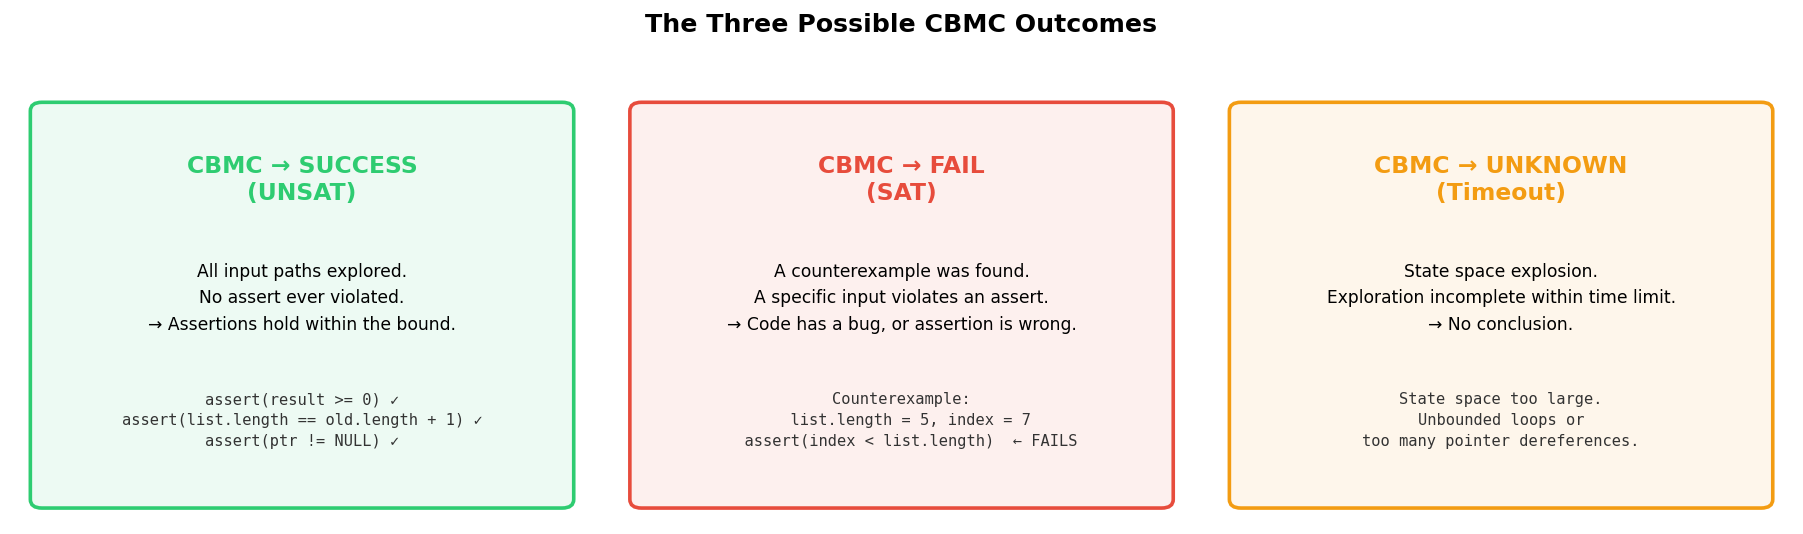

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

scenarios = [
    {
        'title': 'CBMC → SUCCESS\n(UNSAT)',
        'color': '#2ecc71',
        'desc': 'All input paths explored.\nNo assert ever violated.\n→ Assertions hold within the bound.',
        'detail': 'assert(result >= 0) ✓\nassert(list.length == old.length + 1) ✓\nassert(ptr != NULL) ✓'
    },
    {
        'title': 'CBMC → FAIL\n(SAT)',
        'color': '#e74c3c',
        'desc': 'A counterexample was found.\nA specific input violates an assert.\n→ Code has a bug, or assertion is wrong.',
        'detail': 'Counterexample:\n  list.length = 5, index = 7\n  assert(index < list.length)  ← FAILS'
    },
    {
        'title': 'CBMC → UNKNOWN\n(Timeout)',
        'color': '#f39c12',
        'desc': 'State space explosion.\nExploration incomplete within time limit.\n→ No conclusion.',
        'detail': 'State space too large.\nUnbounded loops or\ntoo many pointer dereferences.'
    }
]

for ax, s in zip(axes, scenarios):
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
        boxstyle='round,pad=0.02', linewidth=2,
        edgecolor=s['color'], facecolor=s['color'] + '15'))
    ax.text(0.5, 0.85, s['title'], ha='center', va='top', fontsize=13,
            fontweight='bold', color=s['color'], transform=ax.transAxes)
    ax.text(0.5, 0.60, s['desc'], ha='center', va='top', fontsize=9.5,
            transform=ax.transAxes, linespacing=1.6)
    ax.text(0.5, 0.30, s['detail'], ha='center', va='top', fontsize=8.5,
            transform=ax.transAxes, family='monospace', color='#333', linespacing=1.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

fig.suptitle('The Three Possible CBMC Outcomes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 2: What is a Proof Harness?

CBMC cannot verify a whole program directly. For each function you want to verify, you write a **proof harness** — a small driver that:

1. **Establishes valid inputs** via `__CPROVER_assume()` — constrains inputs to the legal domain
2. **Calls the function under test**
3. **States the properties to verify** via `assert()` — "after the call, these things must hold"

Below is the Ground Truth (GT) harness written by AWS formal verification engineers for `aws_array_list_erase`:

In [3]:
gt_harness = '''
void aws_array_list_erase_harness() {
    struct aws_array_list list;   // declare the array list (symbolic)
    size_t index;                 // index to erase (nondeterministic)

    // ① ASSUMES: restrict CBMC to valid inputs only
    __CPROVER_assume(aws_array_list_is_bounded(&list, MAX_INITIAL_ITEM_ALLOCATION, MAX_ITEM_SIZE));
    ensure_array_list_has_allocated_data_member(&list);
    __CPROVER_assume(aws_array_list_is_valid(&list));

    // ② Snapshot state before the call
    struct aws_array_list old = list;
    struct store_byte_from_buffer old_byte;
    save_byte_from_array((uint8_t *)list.data, list.current_size, &old_byte);

    // ③ Call the function under verification
    if (aws_array_list_erase(&list, index) == AWS_OP_SUCCESS) {

        // ④ ASSERTS: postconditions on success
        assert(list.length == old.length - 1);         // length decremented
        assert(list.item_size == old.item_size);        // item_size unchanged
        assert(list.alloc == old.alloc);                // allocator unchanged
        assert(list.current_size == old.current_size);  // capacity unchanged
        assert(index < old.length);                     // index was in bounds

    } else {
        // ④' On failure: list must be unmodified
        assert_array_list_equivalence(&list, &old, &old_byte);
    }
    // Structural invariant must hold regardless of outcome
    assert(aws_array_list_is_valid(&list));
}
'''

print('AWS Engineer Ground Truth Harness (aws_array_list_erase):')
print(gt_harness)
print('Total assert():', gt_harness.count('assert(') + gt_harness.count('assert_array'))
print('Total assume():', gt_harness.count('__CPROVER_assume'))

AWS Engineer Ground Truth Harness (aws_array_list_erase):

void aws_array_list_erase_harness() {
    struct aws_array_list list;   // declare the array list (symbolic)
    size_t index;                 // index to erase (nondeterministic)

    // ① ASSUMES: restrict CBMC to valid inputs only
    __CPROVER_assume(aws_array_list_is_bounded(&list, MAX_INITIAL_ITEM_ALLOCATION, MAX_ITEM_SIZE));
    ensure_array_list_has_allocated_data_member(&list);
    __CPROVER_assume(aws_array_list_is_valid(&list));

    // ② Snapshot state before the call
    struct aws_array_list old = list;
    struct store_byte_from_buffer old_byte;
    save_byte_from_array((uint8_t *)list.data, list.current_size, &old_byte);

    // ③ Call the function under verification
    if (aws_array_list_erase(&list, index) == AWS_OP_SUCCESS) {

        // ④ ASSERTS: postconditions on success
        assert(list.length == old.length - 1);         // length decremented
        assert(list.item_size == old.item_size);        // 

---
## Part 3: The Experiment Pipeline — How LLMs Generate Harnesses

We ask an LLM (gpt-oss-120b) to generate a harness, run CBMC, feed back the result, and repeat up to 15 iterations:

```
LLM generates iter_1_harness.c
        ↓
   CBMC runs
     ↙    ↘      ↘
 SUCCESS   FAIL   UNKNOWN
   ↓        ↓        ↓
  Done   "fix this   "state space too large,
         assertion"   simplify your harness"
              ↓            ↓
          LLM generates iter_2_harness.c
              ↓
           continue...
```

**The critical question: what does the LLM do when CBMC returns UNKNOWN?**

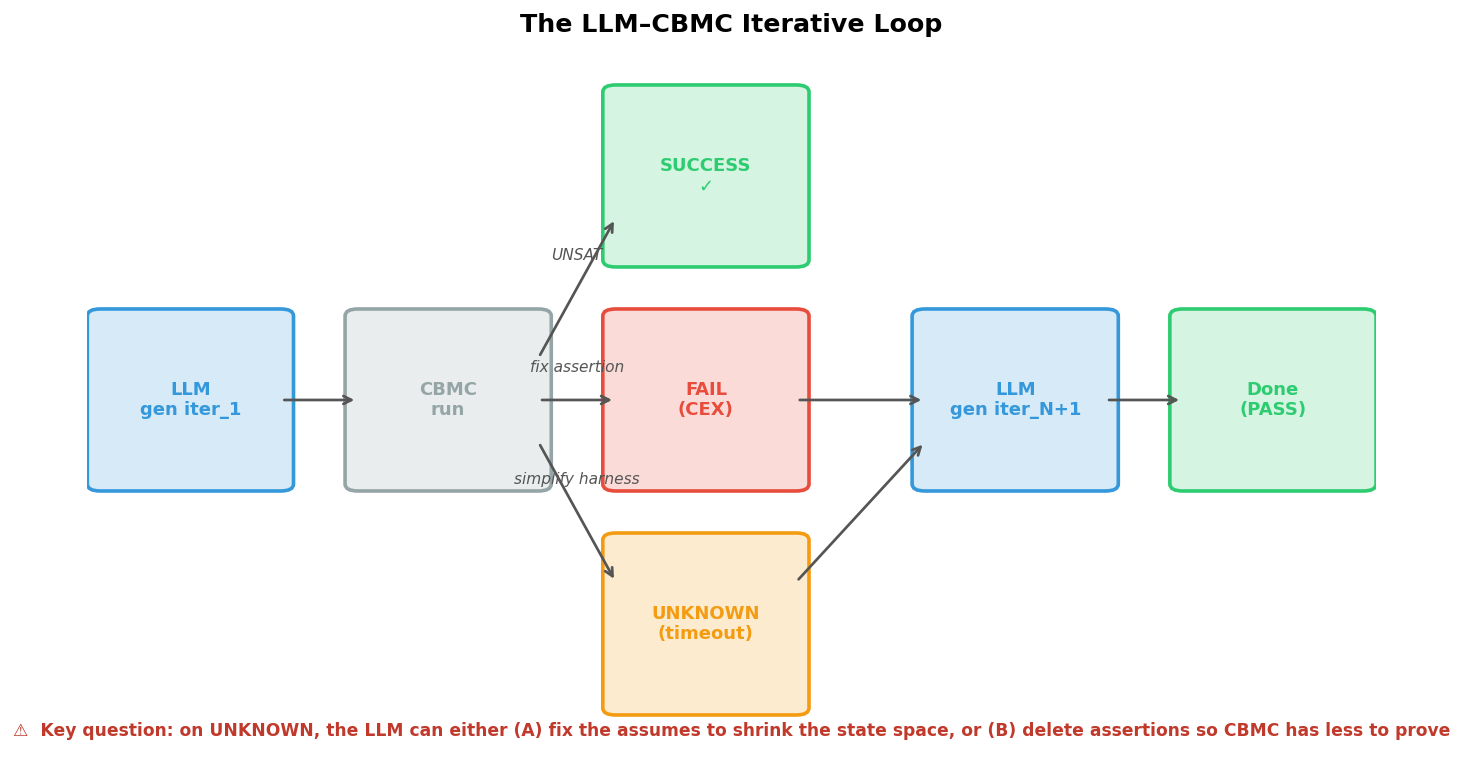

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

boxes = [
    (0.08, 0.5,  'LLM\ngen iter_1',     '#3498db'),
    (0.28, 0.5,  'CBMC\nrun',            '#95a5a6'),
    (0.48, 0.82, 'SUCCESS\n✓',           '#2ecc71'),
    (0.48, 0.5,  'FAIL\n(CEX)',          '#e74c3c'),
    (0.48, 0.18, 'UNKNOWN\n(timeout)',   '#f39c12'),
    (0.72, 0.5,  'LLM\ngen iter_N+1',   '#3498db'),
    (0.92, 0.5,  'Done\n(PASS)',         '#2ecc71'),
]
for x, y, label, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-0.07, y-0.12), 0.14, 0.24,
        boxstyle='round,pad=0.01', linewidth=2,
        edgecolor=color, facecolor=color + '33'))
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            fontweight='bold', color=color)

arrows = [
    (0.15, 0.5,  0.21, 0.5,  ''),
    (0.35, 0.56, 0.41, 0.76, 'UNSAT'),
    (0.35, 0.5,  0.41, 0.5,  'fix assertion'),
    (0.35, 0.44, 0.41, 0.24, 'simplify harness'),
    (0.55, 0.5,  0.65, 0.5,  ''),
    (0.55, 0.24, 0.65, 0.44, ''),
    (0.79, 0.5,  0.85, 0.5,  ''),
]
for x1, y1, x2, y2, label in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.04, label,
                ha='center', fontsize=8.5, color='#555', style='italic')

ax.text(0.5, 0.02,
    '⚠️  Key question: on UNKNOWN, the LLM can either '
    '(A) fix the assumes to shrink the state space, or '
    '(B) delete assertions so CBMC has less to prove',
    ha='center', fontsize=9.5, color='#c0392b', fontweight='bold')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('The LLM–CBMC Iterative Loop', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Part 4: A Real Sacrifice Case — aws_array_list_erase

Here is what actually happened: the LLM deleted **8 assertions** after receiving a CBMC UNKNOWN.

In [5]:
func = 'aws_array_list_erase'
result_dir = os.path.join(RESULTS, 'feedback_loop_A_gptoss120b', func)

with open(os.path.join(result_dir, 'summary.json')) as f:
    summary = json.load(f)

iter_files = sorted([f for f in os.listdir(result_dir)
                     if f.startswith('iter_') and f.endswith('_harness.c')])
iter_code = {}
iter_asserts = {}
for fname in iter_files:
    num = int(fname.split('_')[1])
    with open(os.path.join(result_dir, fname)) as f:
        code = f.read()
    iter_code[num] = code
    n = sum(1 for line in code.splitlines()
            if 'assert(' in line and '__CPROVER_assume' not in line
            and not line.strip().startswith('//'))
    iter_asserts[num] = n

print(f'Function: {func}')
print(f'Total iterations: {len(summary["iterations"])}')
print()
icons = {'SUCCESS': '✅', 'FAIL': '❌', 'UNKNOWN': '⚠️', 'COMPILE_ERROR': '🔧'}
for it in summary['iterations']:
    n = iter_asserts.get(it['iter'], '?')
    print(f"  Iter {it['iter']}: {icons.get(it['verify'], '?')} {it['verify']:15s} "
          f"assertions: {n}  action: {it['action']}")

Function: aws_array_list_erase
Total iterations: 3

  Iter 1: ⚠️ UNKNOWN         assertions: 15  action: initial
  Iter 2: ⚠️ UNKNOWN         assertions: 7  action: fix_unknown
  Iter 3: ✅ SUCCESS         assertions: 10  action: fix_unknown


In [6]:
def extract_asserts(code):
    return [line.strip() for line in code.splitlines()
            if 'assert(' in line and '__CPROVER_assume' not in line
            and not line.strip().startswith('//') and '#include' not in line]

asserts_1 = extract_asserts(iter_code[1])
asserts_2 = extract_asserts(iter_code[2])
set_1, set_2 = set(asserts_1), set(asserts_2)

print('=' * 65)
print(f'ITER 1 — {len(asserts_1)} assertions  →  CBMC: UNKNOWN')
print('=' * 65)
for a in asserts_1:
    tag = '❌ DELETED' if a not in set_2 else '   kept   '
    print(f'  {tag}  {a}')

print()
print('=' * 65)
print(f'ITER 2 — {len(asserts_2)} assertions  →  CBMC: SUCCESS')
print('=' * 65)
for a in asserts_2:
    tag = '✨ NEW' if a not in set_1 else '      '
    print(f'  {tag}  {a}')

print()
print(f'Deleted: {len(set_1 - set_2)}  |  Added: {len(set_2 - set_1)}')

ITER 1 — 15 assertions  →  CBMC: UNKNOWN
     kept     assert(list.length == old.length - 1);
     kept     assert(list.alloc == old.alloc);
     kept     assert(list.item_size == old.item_size);
     kept     assert(list.data == old.data);
     kept     assert(list.current_size == old.current_size);
     kept     assert(list.length == old.length);
     kept     assert(list.alloc == old.alloc);
     kept     assert(list.item_size == old.item_size);
     kept     assert(list.data == old.data);
     kept     assert(list.current_size == old.current_size);
     kept     assert(list.alloc == old.alloc);
     kept     assert(list.item_size == old.item_size);
     kept     assert(list.data == old.data);
     kept     assert(list.current_size == old.current_size);
     kept     assert(aws_array_list_is_valid(&list));

ITER 2 — 7 assertions  →  CBMC: SUCCESS
          assert(list.length == old.length - 1);
          assert(list.length == old.length);
          assert(list.alloc == old.alloc);
 

In [7]:
# Compare final LLM harness against GT
gt_asserts_keywords = [
    ('assert(list.length == old.length - 1)', 'length decremented'),
    ('assert(list.item_size == old.item_size)', 'item_size frame'),
    ('assert(list.alloc == old.alloc)', 'alloc frame'),
    ('assert(list.current_size == old.current_size)', 'current_size frame'),
    ('assert(index < old.length)', 'index validity'),
    ('assert_array_list_equivalence', 'failure equivalence'),
    ('assert(aws_array_list_is_valid', 'structural invariant'),
]

print('GT assertion coverage in LLM final harness (iter_2):')
print()
for gt_assert, desc in gt_asserts_keywords:
    key = gt_assert.split('(')[1].split(')')[0][:25] if '(' in gt_assert else gt_assert[:25]
    in_iter1 = any(key[:15] in a for a in asserts_1)
    in_final = any(key[:15] in a for a in asserts_2)
    if in_final:
        status = '✅ MATCHED'
    elif in_iter1:
        status = '⚠️  SACRIFICE  (generated then deleted)'
    else:
        status = '❌ KNOWLEDGE GAP  (never generated)'
    print(f'  {status:<42}  [{desc}]')

GT assertion coverage in LLM final harness (iter_2):

  ✅ MATCHED                                   [length decremented]
  ✅ MATCHED                                   [item_size frame]
  ✅ MATCHED                                   [alloc frame]
  ✅ MATCHED                                   [current_size frame]
  ❌ KNOWLEDGE GAP  (never generated)          [index validity]
  ❌ KNOWLEDGE GAP  (never generated)          [failure equivalence]
  ✅ MATCHED                                   [structural invariant]


---
## Part 5: PASS Rate vs Recall — Why PASS Rate is a Misleading Metric

**PASS rate**: fraction of functions where the LLM harness passes CBMC verification.  
**Recall**: fraction of GT assertions that the LLM harness covers (measured by re-running LLM assertions under GT assumes).

**Central finding: higher PASS rate does not imply higher recall — the ordering reverses.**

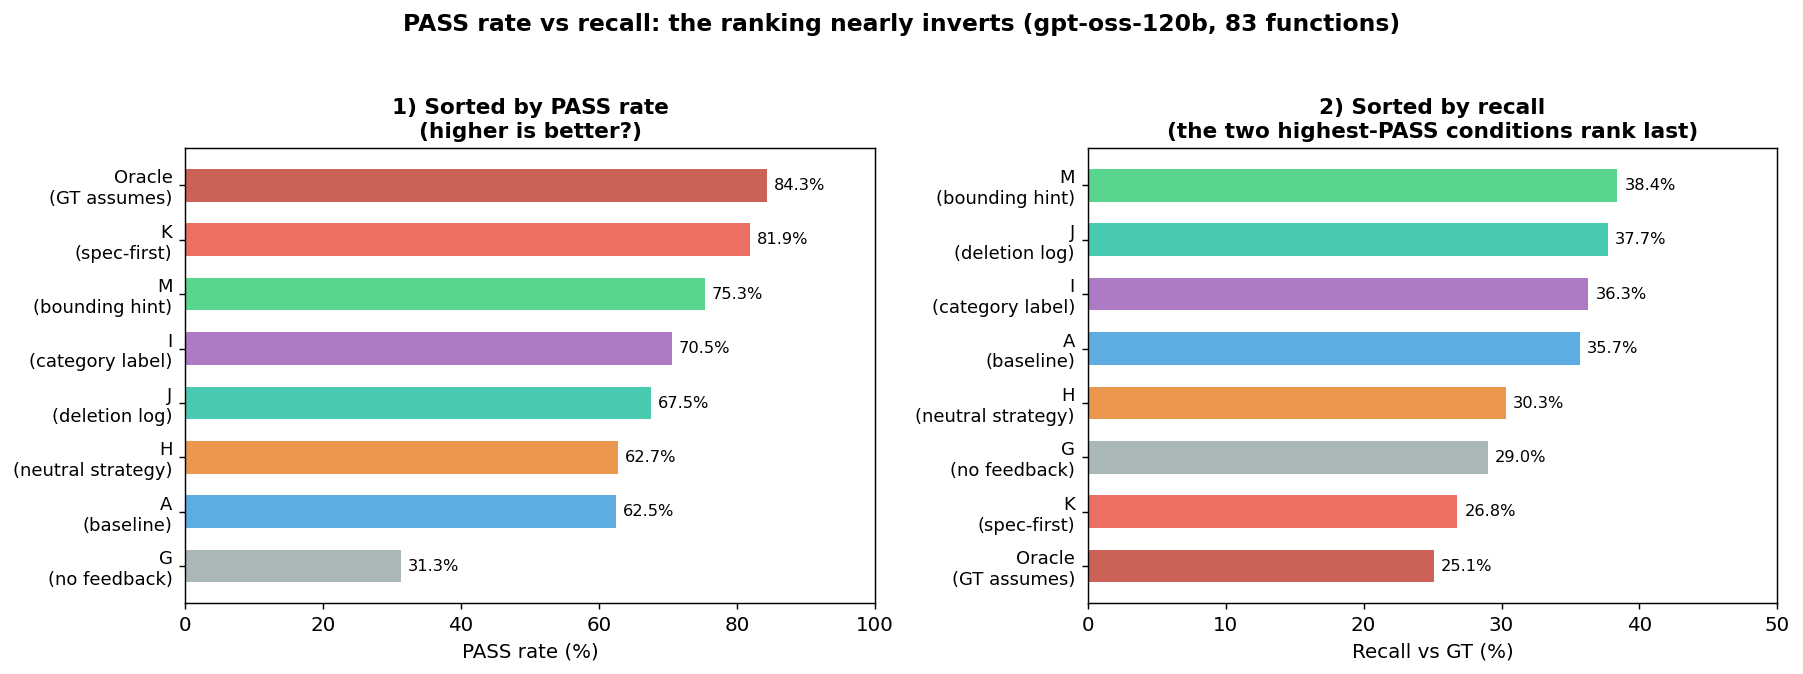

In [8]:
# Canonical RQ1 data (paper.tex Table 2 / tab:rq1_main)
conditions_data = {
    'G\n(no feedback)':      {'pass': 31.3, 'recall': 0.290, 'sacrifice': None, 'color': '#95a5a6'},
    'H\n(neutral strategy)': {'pass': 62.7, 'recall': 0.303, 'sacrifice': 86.3, 'color': '#e67e22'},
    'A\n(baseline)':         {'pass': 62.5, 'recall': 0.357, 'sacrifice': 81.8, 'color': '#3498db'},
    'I\n(category label)':   {'pass': 70.5, 'recall': 0.363, 'sacrifice': 92.7, 'color': '#9b59b6'},
    'J\n(deletion log)':     {'pass': 67.5, 'recall': 0.377, 'sacrifice': 93.0, 'color': '#1abc9c'},
    'K\n(spec-first)':       {'pass': 81.9, 'recall': 0.268, 'sacrifice': 25.0, 'color': '#e74c3c'},
    'Oracle\n(GT assumes)':  {'pass': 84.3, 'recall': 0.251, 'sacrifice': 11.8, 'color': '#c0392b'},
    'M\n(bounding hint)':    {'pass': 75.3, 'recall': 0.384, 'sacrifice': 0.0,  'color': '#2ecc71'},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(conditions_data.keys())

ax = axes[0]
sorted_pass = sorted(zip([conditions_data[n]['pass'] for n in names], names,
                         [conditions_data[n]['color'] for n in names]), reverse=True)
p_s, n_s, c_s = zip(*sorted_pass)
ax.barh(range(len(n_s)), p_s, color=c_s, alpha=0.8, height=0.6)
ax.set_yticks(range(len(n_s))); ax.set_yticklabels(n_s, fontsize=10)
ax.set_xlabel('PASS rate (%)'); ax.set_xlim(0, 100); ax.invert_yaxis()
ax.set_title('1) Sorted by PASS rate\n(higher is better?)', fontsize=12, fontweight='bold')
for i, p in enumerate(p_s): ax.text(p + 1, i, f'{p:.1f}%', va='center', fontsize=9)

ax = axes[1]
sorted_rec = sorted(zip([conditions_data[n]['recall']*100 for n in names], names,
                        [conditions_data[n]['color'] for n in names]), reverse=True)
r_s, n_s2, c_s2 = zip(*sorted_rec)
ax.barh(range(len(n_s2)), r_s, color=c_s2, alpha=0.8, height=0.6)
ax.set_yticks(range(len(n_s2))); ax.set_yticklabels(n_s2, fontsize=10)
ax.set_xlabel('Recall vs GT (%)'); ax.set_xlim(0, 50); ax.invert_yaxis()
ax.set_title('2) Sorted by recall\n(the two highest-PASS conditions rank last)', fontsize=12, fontweight='bold')
for i, r in enumerate(r_s): ax.text(r + 0.5, i, f'{r:.1f}%', va='center', fontsize=9)

fig.suptitle('PASS rate vs recall: the ranking nearly inverts (gpt-oss-120b, 83 functions)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

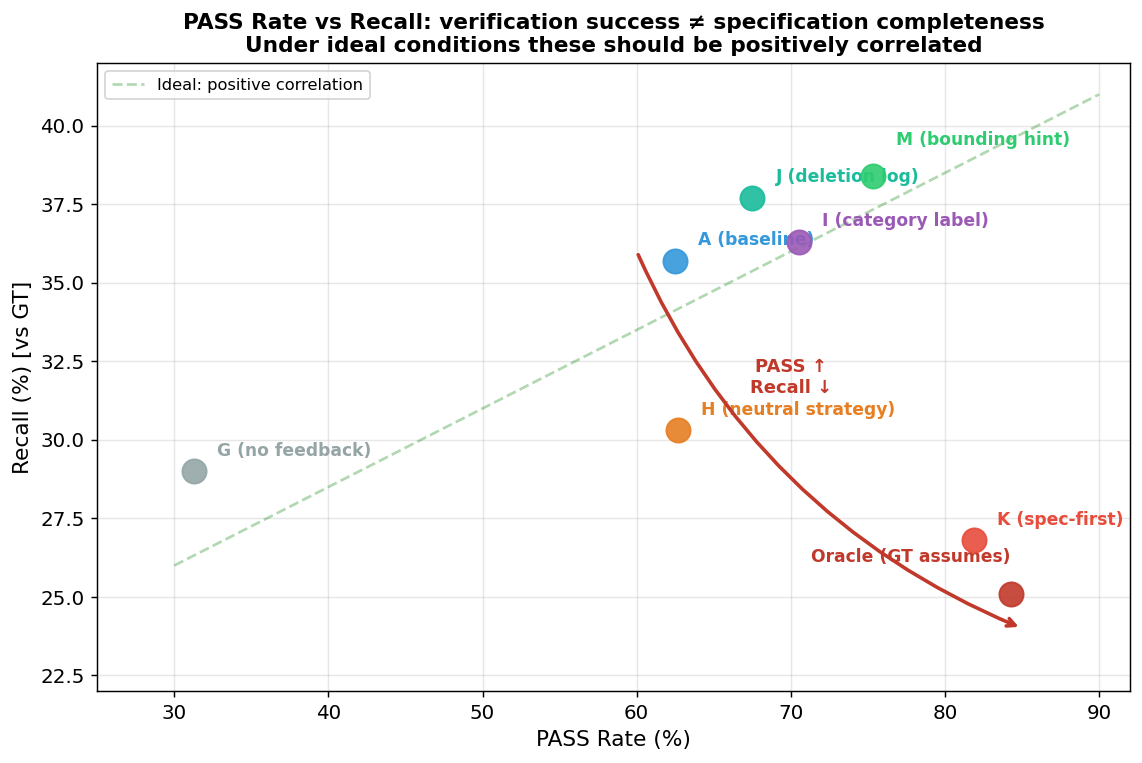

In [9]:
# Scatter: PASS rate vs Recall — shows the negative correlation
fig, ax = plt.subplots(figsize=(9, 6))

for name, d in conditions_data.items():
    short = name.replace('\n', ' ')
    ax.scatter(d['pass'], d['recall'] * 100, s=180, color=d['color'], zorder=5, alpha=0.9)
    ox, oy = 1.5, 0.5
    if 'Oracle' in name: ox, oy = -13, 1
    elif 'M' in name: oy = 1
    ax.annotate(short, xy=(d['pass'], d['recall']*100),
                xytext=(d['pass']+ox, d['recall']*100+oy),
                fontsize=9.5, color=d['color'], fontweight='bold')

ax.annotate('', xy=(85, 24), xytext=(60, 36),
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2,
                    connectionstyle='arc3,rad=0.2'))
ax.text(70, 31.5, 'PASS ↑\nRecall ↓', color='#c0392b', fontsize=10,
        fontweight='bold', ha='center')

ax.plot([30, 90], [26, 41], 'g--', alpha=0.3, label='Ideal: positive correlation')
ax.set_xlabel('PASS Rate (%)', fontsize=12)
ax.set_ylabel('Recall (%) [vs GT]', fontsize=12)
ax.set_title('PASS Rate vs Recall: verification success ≠ specification completeness\n'
             'Under ideal conditions these should be positively correlated',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(25, 92); ax.set_ylim(22, 42)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 6: Why Does the Ranking Reverse? — Three Mechanisms

| Condition | Why high PASS | Why low Recall |
|-----------|--------------|----------------|
| **Oracle** | GT assumes provide perfect state constraints | **Laziness effect**: assumes are so good that trivial assertions pass CBMC — LLM writes minimal postconditions |
| **K** | NL contract written first → harness starts from a strong base | NL contract itself is incomplete — omits GT postconditions not obvious from the spec |
| **A** | Iterative CBMC repair improves PASS | Some correct assertions deleted under UNKNOWN pressure (sacrifice) |
| **M** | Bounding hint eliminates UNKNOWN events | Zero deletions — all assertions retained, recall is highest |

---
## Part 7: Two "deletion" numbers — deleting a lot != silencing a lot

Two figures that are easy to conflate (both Condition A / gpt-oss-120b):

- **81.8% sacrifice ratio** (RQ1, iteration-log level): of all delete/weaken events, 81.8% are triggered by **UNKNOWN** (not by FAIL). It measures the *motive* for deletion.
- **90.2% KG** (RQ2, silenced-bug level): of the 41 silenced bugs, 90.2% are attributed to assertions that were **never generated** (knowledge gap) — SAC is 0%.

Not a contradiction: different denominators. gptoss deletes aggressively, but mostly its own over-generated assertions that were not catching mutants anyway; the bugs it loses come from assertions it **never knew to write** (CA capacity arithmetic, FC-RV return values). SAC only becomes safety-relevant on the stronger model (Claude: 37.5%, see Part 14).


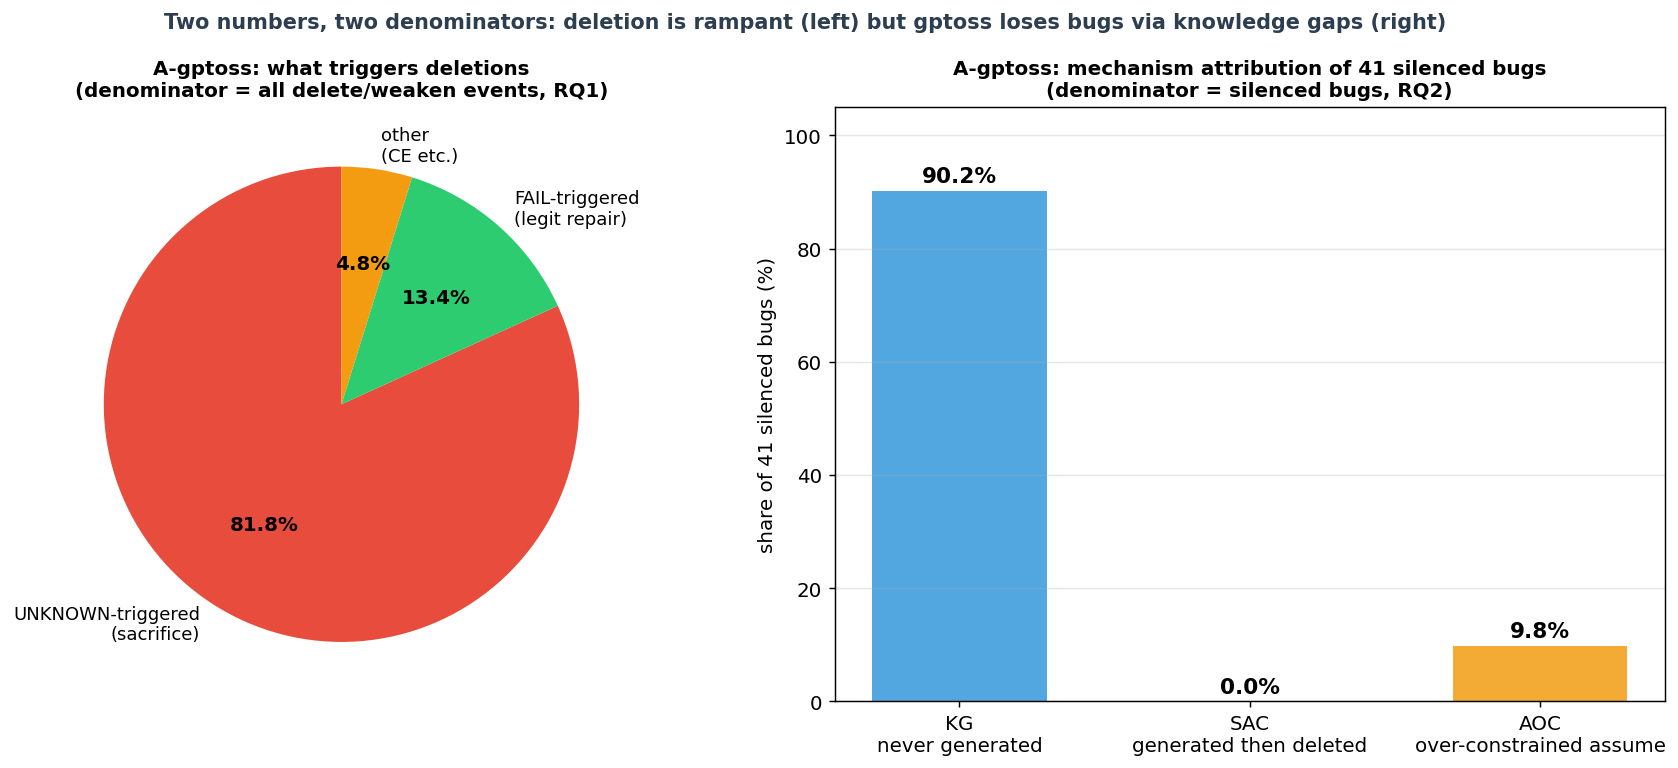

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
labels = ['UNKNOWN-triggered\n(sacrifice)', 'FAIL-triggered\n(legit repair)', 'other\n(CE etc.)']
sizes = [81.8, 13.4, 4.8]
colors = ['#e74c3c', '#2ecc71', '#f39c12']
w, t, at = ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                  startangle=90, textprops={'fontsize': 10})
for a in at: a.set_fontsize(11); a.set_fontweight('bold')
ax.set_title('A-gptoss: what triggers deletions\n(denominator = all delete/weaken events, RQ1)',
             fontsize=11, fontweight='bold')

ax = axes[1]
cats = ['KG\nnever generated', 'SAC\ngenerated then deleted', 'AOC\nover-constrained assume']
vals = [90.2, 0.0, 9.8]
bars = ax.bar(cats, vals, color=['#3498db', '#e74c3c', '#f39c12'], alpha=0.85, width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('share of 41 silenced bugs (%)'); ax.set_ylim(0, 105)
ax.set_title('A-gptoss: mechanism attribution of 41 silenced bugs\n(denominator = silenced bugs, RQ2)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Two numbers, two denominators: deletion is rampant (left) but gptoss loses bugs via knowledge gaps (right)',
             fontsize=11.5, fontweight='bold', color='#2c3e50')
plt.tight_layout(); plt.show()

---
## Part 8: The 8 Experimental Conditions

Parts 4–7 established that deletion is rampant. The natural next question is **why it happens**. We designed 8 conditions that each change **exactly one variable** relative to baseline A — ruling candidate explanations in or out one at a time.

Each condition changes **exactly one variable** to isolate a specific causal question.

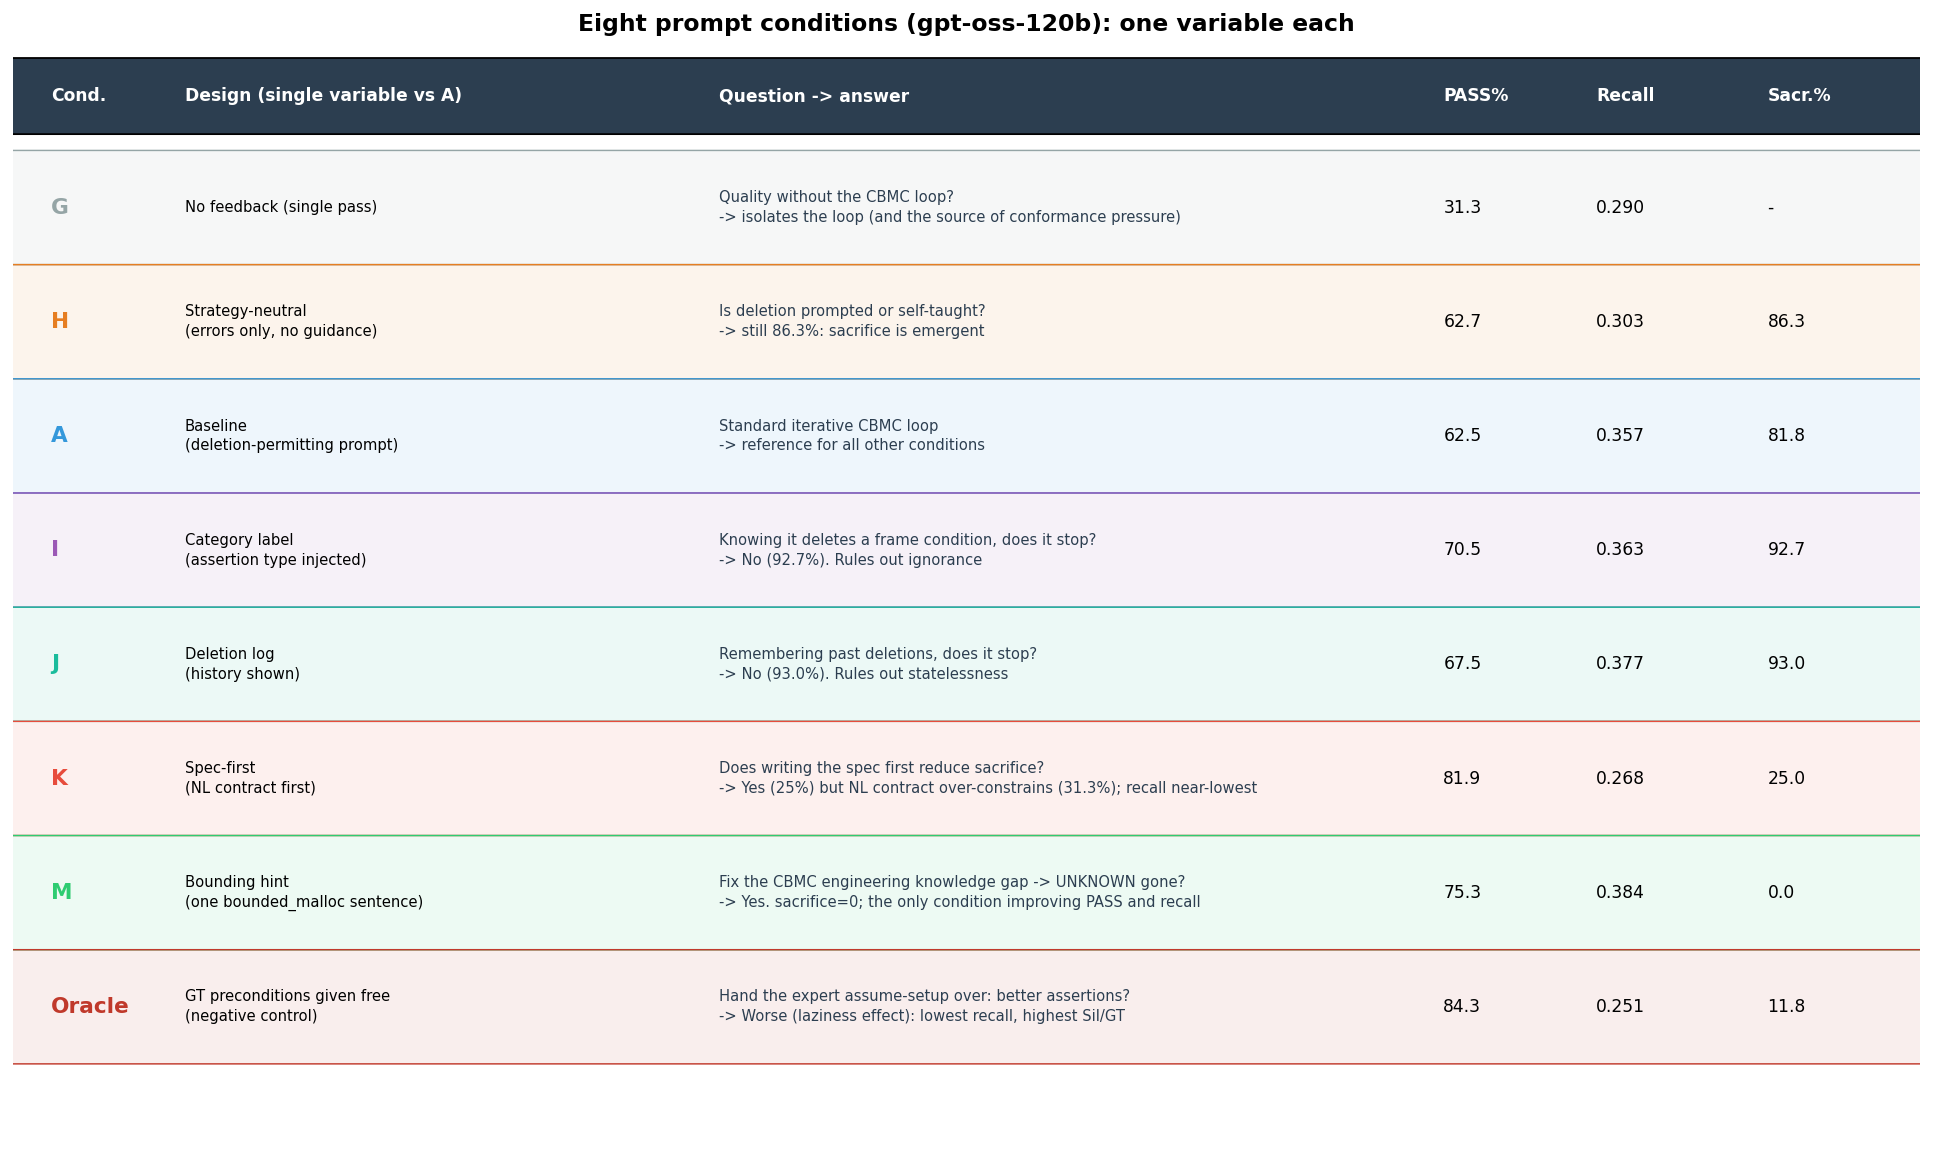

In [11]:
# The 8 prompt conditions: each changes exactly one variable relative to A
conditions_info = [
    ('G', 'No feedback (single pass)', 'Quality without the CBMC loop?\n-> isolates the loop (and the source of conformance pressure)', 31.3, 0.290, None, '#95a5a6'),
    ('H', 'Strategy-neutral\n(errors only, no guidance)', 'Is deletion prompted or self-taught?\n-> still 86.3%: sacrifice is emergent', 62.7, 0.303, 86.3, '#e67e22'),
    ('A', 'Baseline\n(deletion-permitting prompt)', 'Standard iterative CBMC loop\n-> reference for all other conditions', 62.5, 0.357, 81.8, '#3498db'),
    ('I', 'Category label\n(assertion type injected)', 'Knowing it deletes a frame condition, does it stop?\n-> No (92.7%). Rules out ignorance', 70.5, 0.363, 92.7, '#9b59b6'),
    ('J', 'Deletion log\n(history shown)', 'Remembering past deletions, does it stop?\n-> No (93.0%). Rules out statelessness', 67.5, 0.377, 93.0, '#1abc9c'),
    ('K', 'Spec-first\n(NL contract first)', 'Does writing the spec first reduce sacrifice?\n-> Yes (25%) but NL contract over-constrains (31.3%); recall near-lowest', 81.9, 0.268, 25.0, '#e74c3c'),
    ('M', 'Bounding hint\n(one bounded_malloc sentence)', 'Fix the CBMC engineering knowledge gap -> UNKNOWN gone?\n-> Yes. sacrifice=0; the only condition improving PASS and recall', 75.3, 0.384, 0.0, '#2ecc71'),
    ('Oracle', 'GT preconditions given free\n(negative control)', 'Hand the expert assume-setup over: better assertions?\n-> Worse (laziness effect): lowest recall, highest Sil/GT', 84.3, 0.251, 11.8, '#c0392b'),
]

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis('off')
col_headers = ['Cond.', 'Design (single variable vs A)', 'Question -> answer', 'PASS%', 'Recall', 'Sacr.%']
col_x = [0.02, 0.09, 0.37, 0.75, 0.83, 0.92]
row_h = 0.105
ax.add_patch(mpatches.FancyBboxPatch((0, 0.93), 1.0, 0.06,
    boxstyle='round,pad=0.005', facecolor='#2c3e50', transform=ax.transAxes))
for x, h in zip(col_x, col_headers):
    ax.text(x, 0.96, h, fontsize=9.5, fontweight='bold', color='white',
            transform=ax.transAxes, va='center')
for i, (cond, intent, question, pr, rc, sa, color) in enumerate(conditions_info):
    y = 0.92 - (i + 1) * row_h
    ax.add_patch(mpatches.FancyBboxPatch((0, y - 0.005), 1.0, row_h - 0.01,
        boxstyle='round,pad=0.005', facecolor=color + '15', transform=ax.transAxes,
        linewidth=0.8, edgecolor=color))
    ax.text(col_x[0], y + row_h/2 - 0.01, cond, fontsize=12, fontweight='bold',
            color=color, transform=ax.transAxes, va='center')
    ax.text(col_x[1], y + row_h/2 - 0.01, intent, fontsize=8.2,
            transform=ax.transAxes, va='center', linespacing=1.4)
    ax.text(col_x[2], y + row_h/2 - 0.01, question, fontsize=8.2,
            transform=ax.transAxes, va='center', linespacing=1.4, color='#2c3e50')
    ax.text(col_x[3], y + row_h/2 - 0.01, f'{pr:.1f}', fontsize=9.5,
            transform=ax.transAxes, va='center')
    ax.text(col_x[4], y + row_h/2 - 0.01, f'{rc:.3f}' if rc is not None else '-',
            fontsize=9.5, transform=ax.transAxes, va='center')
    ax.text(col_x[5], y + row_h/2 - 0.01, f'{sa:.1f}' if sa is not None else '-',
            fontsize=9.5, transform=ax.transAxes, va='center')
ax.set_title('Eight prompt conditions (gpt-oss-120b): one variable each',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

---
## Part 9: Deletion Scope — Panic Deletion vs Targeted Deletion

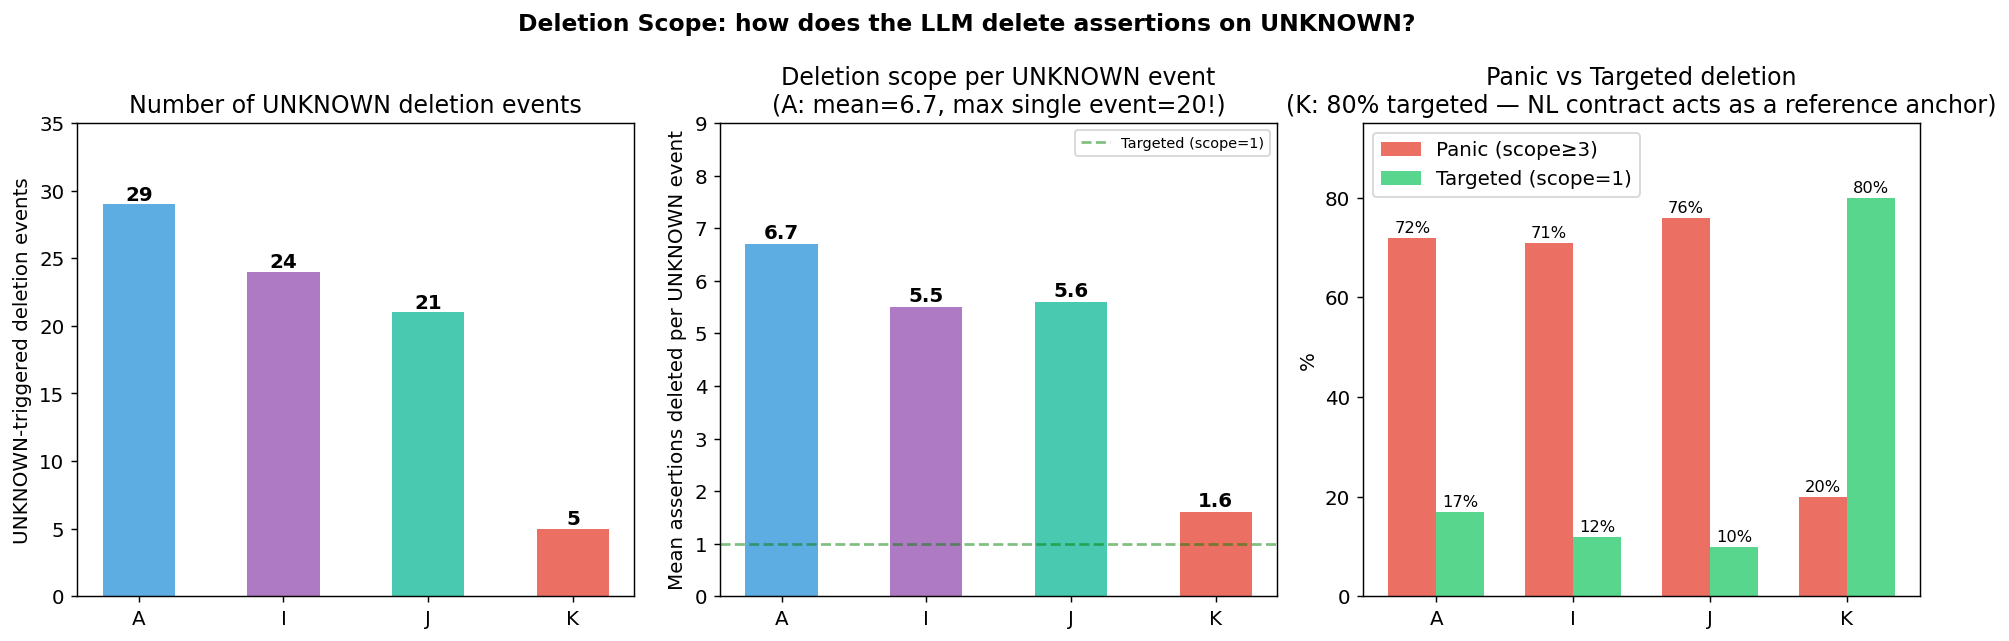


Interpretation:
  A/I/J: 72-76% panic deletion — CBMC times out, LLM cannot diagnose which assertion
         causes UNKNOWN, so it clears all assertions in a single sweep
  K:     80% targeted — the written NL contract gives the LLM a reference to pinpoint
         which specific assertion conflicts with the CBMC state space constraint
  M:     0 deletion events — UNKNOWN eliminated; no deletion pressure at all


In [12]:
deletion_scope_data = {
    'A':  {'events': 29, 'mean_scope': 6.7, 'panic_pct': 72, 'targeted_pct': 17, 'color': '#3498db'},
    'I':  {'events': 24, 'mean_scope': 5.5, 'panic_pct': 71, 'targeted_pct': 12, 'color': '#9b59b6'},
    'J':  {'events': 21, 'mean_scope': 5.6, 'panic_pct': 76, 'targeted_pct': 10, 'color': '#1abc9c'},
    'K':  {'events': 5,  'mean_scope': 1.6, 'panic_pct': 20, 'targeted_pct': 80, 'color': '#e74c3c'},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cnames = list(deletion_scope_data.keys())
colors_ds = [deletion_scope_data[c]['color'] for c in cnames]

ax = axes[0]
events = [deletion_scope_data[c]['events'] for c in cnames]
ax.bar(cnames, events, color=colors_ds, alpha=0.8, width=0.5)
ax.set_ylabel('UNKNOWN-triggered deletion events')
ax.set_title('Number of UNKNOWN deletion events')
for i, e in enumerate(events):
    ax.text(i, e + 0.3, str(e), ha='center', fontweight='bold')
ax.set_ylim(0, 35)

ax = axes[1]
means = [deletion_scope_data[c]['mean_scope'] for c in cnames]
ax.bar(cnames, means, color=colors_ds, alpha=0.8, width=0.5)
ax.set_ylabel('Mean assertions deleted per UNKNOWN event')
ax.set_title('Deletion scope per UNKNOWN event\n(A: mean=6.7, max single event=20!)')
for i, m in enumerate(means):
    ax.text(i, m + 0.1, f'{m:.1f}', ha='center', fontweight='bold')
ax.set_ylim(0, 9)
ax.axhline(1, color='green', linestyle='--', alpha=0.5, label='Targeted (scope=1)')
ax.legend(fontsize=8)

ax = axes[2]
panic = [deletion_scope_data[c]['panic_pct'] for c in cnames]
targeted = [deletion_scope_data[c]['targeted_pct'] for c in cnames]
x = np.arange(len(cnames)); w = 0.35
b1 = ax.bar(x - w/2, panic, width=w, label='Panic (scope≥3)', color='#e74c3c', alpha=0.8)
b2 = ax.bar(x + w/2, targeted, width=w, label='Targeted (scope=1)', color='#2ecc71', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(cnames)
ax.set_ylabel('%')
ax.set_title('Panic vs Targeted deletion\n(K: 80% targeted — NL contract acts as a reference anchor)')
ax.legend(); ax.set_ylim(0, 95)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)

fig.suptitle('Deletion Scope: how does the LLM delete assertions on UNKNOWN?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  A/I/J: 72-76% panic deletion — CBMC times out, LLM cannot diagnose which assertion')
print('         causes UNKNOWN, so it clears all assertions in a single sweep')
print('  K:     80% targeted — the written NL contract gives the LLM a reference to pinpoint')
print('         which specific assertion conflicts with the CBMC state space constraint')
print('  M:     0 deletion events — UNKNOWN eliminated; no deletion pressure at all')

---
## Part 10: Statistical Significance

Wilcoxon signed-rank tests on per-function strict recall, paired on shared functions with GT assertions.

In [13]:
from scipy.stats import wilcoxon

def load_recall(path):
    with open(path) as f:
        entries = json.load(f)
    return {e['func']: (e['harness_recall'] if e['harness_recall'] is not None else 0.0)
            for e in entries if e['gt_harness_count'] > 0}

cond_paths = {
    'A':      os.path.join(EVAL, 'cross_verify_results_condA_gptoss120b.json'),
    'H':      os.path.join(EVAL, 'cross_verify_results_condH_gptoss120b.json'),
    'G':      os.path.join(EVAL, 'cross_verify_results_condG_gptoss120b.json'),
    'K':      os.path.join(EVAL, 'cross_verify_results_condK_gptoss120b.json'),
    'Oracle': os.path.join(EVAL, 'cross_verify_results_condOracle_gptoss120b.json'),
    'M':      os.path.join(EVAL, 'cross_verify_results_condM_gptoss120b.json'),
}
recalls = {k: load_recall(v) for k, v in cond_paths.items()}

tests = [
    ('M', 'Oracle', 'Laziness effect reversal: M > Oracle'),
    ('M', 'K',      'PASS-recall reversal: M > K'),
    ('M', 'H',      'Bounding hint effect: M > H'),
    ('A', 'Oracle', 'Laziness effect: A > Oracle (GT assumes actually hurt recall)'),
    ('A', 'K',      'Spec-first does not improve recall: A > K'),
    ('A', 'H',      'Strategy guidance matters: A > H (same PASS rate, higher recall)'),
    ('M', 'A',      'M vs A (marginal, ns)'),
]

print(f'{"Comparison":<50} {"n":>4} {"Δmean recall":>13} {"p (one-sided)":>15} {"Sig":>6}')
print('-'*93)

results_plot = []
for c1, c2, label in tests:
    shared = sorted(set(recalls[c1]) & set(recalls[c2]))
    v1 = np.array([recalls[c1][f] for f in shared])
    v2 = np.array([recalls[c2][f] for f in shared])
    mean_diff = np.mean(v1) - np.mean(v2)
    nz = np.sum(v1 != v2)
    if nz >= 6:
        _, p = wilcoxon(v1, v2, alternative='greater')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        results_plot.append((label[:40], mean_diff, p, sig))
        print(f'{label:<50} {len(shared):>4} {mean_diff:>+13.4f} {p:>15.4f} {sig:>6}')

print()
print('* p<0.05  ** p<0.01  *** p<0.001  (Wilcoxon signed-rank, one-sided, strict recall)')

Comparison                                            n  Δmean recall   p (one-sided)    Sig
---------------------------------------------------------------------------------------------
Laziness effect reversal: M > Oracle                 82       +0.1351          0.0008    ***
PASS-recall reversal: M > K                          82       +0.1174          0.0022     **
Bounding hint effect: M > H                          82       +0.0821          0.0033     **
Laziness effect: A > Oracle (GT assumes actually hurt recall)   79       +0.0985          0.0218      *
Spec-first does not improve recall: A > K            79       +0.0801          0.0350      *
Strategy guidance matters: A > H (same PASS rate, higher recall)   79       +0.0561          0.0258      *
M vs A (marginal, ns)                                79       +0.0354          0.0769     ns

* p<0.05  ** p<0.01  *** p<0.001  (Wilcoxon signed-rank, one-sided, strict recall)


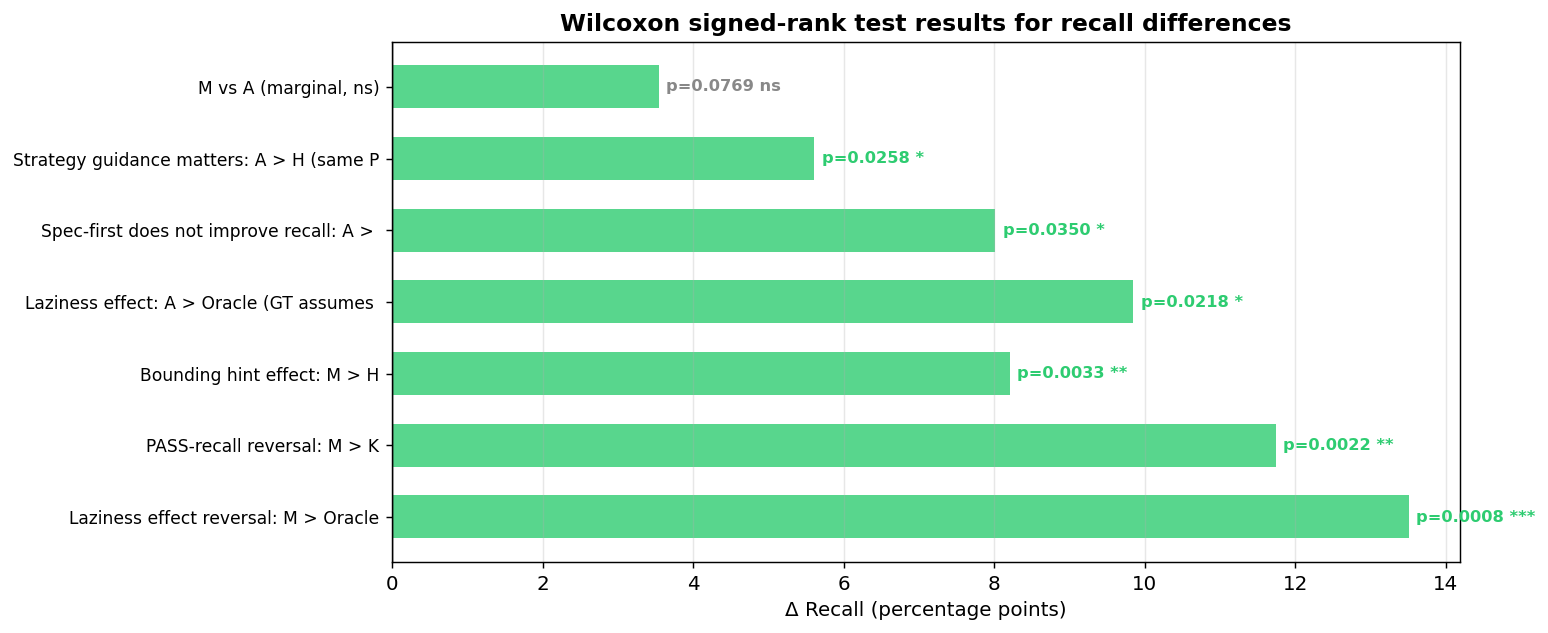

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

labels_p = [r[0] for r in results_plot]
diffs = [r[1] * 100 for r in results_plot]
pvals = [r[2] for r in results_plot]
sigs  = [r[3] for r in results_plot]

bar_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
ax.barh(range(len(labels_p)), diffs, color=bar_colors, alpha=0.8, height=0.6)
ax.set_yticks(range(len(labels_p)))
ax.set_yticklabels(labels_p, fontsize=9.5)
ax.set_xlabel('Δ Recall (percentage points)', fontsize=11)
ax.set_title('Wilcoxon signed-rank test results for recall differences',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

for i, (d, p, s) in enumerate(zip(diffs, pvals, sigs)):
    x_pos = d + (0.1 if d >= 0 else -0.1)
    ha = 'left' if d >= 0 else 'right'
    color = '#2ecc71' if s != 'ns' else '#888'
    ax.text(x_pos, i, f'p={p:.4f} {s}', va='center', ha=ha,
            fontsize=9, fontweight='bold', color=color)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## Part 11: Vacuity Check — Are Our Results Genuine?

**Concern**: K and Oracle have very tight `__CPROVER_assume` constraints. Could their high PASS rate be *vacuous success* — the assumes filter out all inputs, so CBMC never reaches the function call, and all assertions trivially hold on an empty path?

**Validation**: inject `__CPROVER_assert(false)` immediately before the function call. If CBMC still returns UNSAT, the call is unreachable → vacuous. If it returns SAT, the path is genuine.

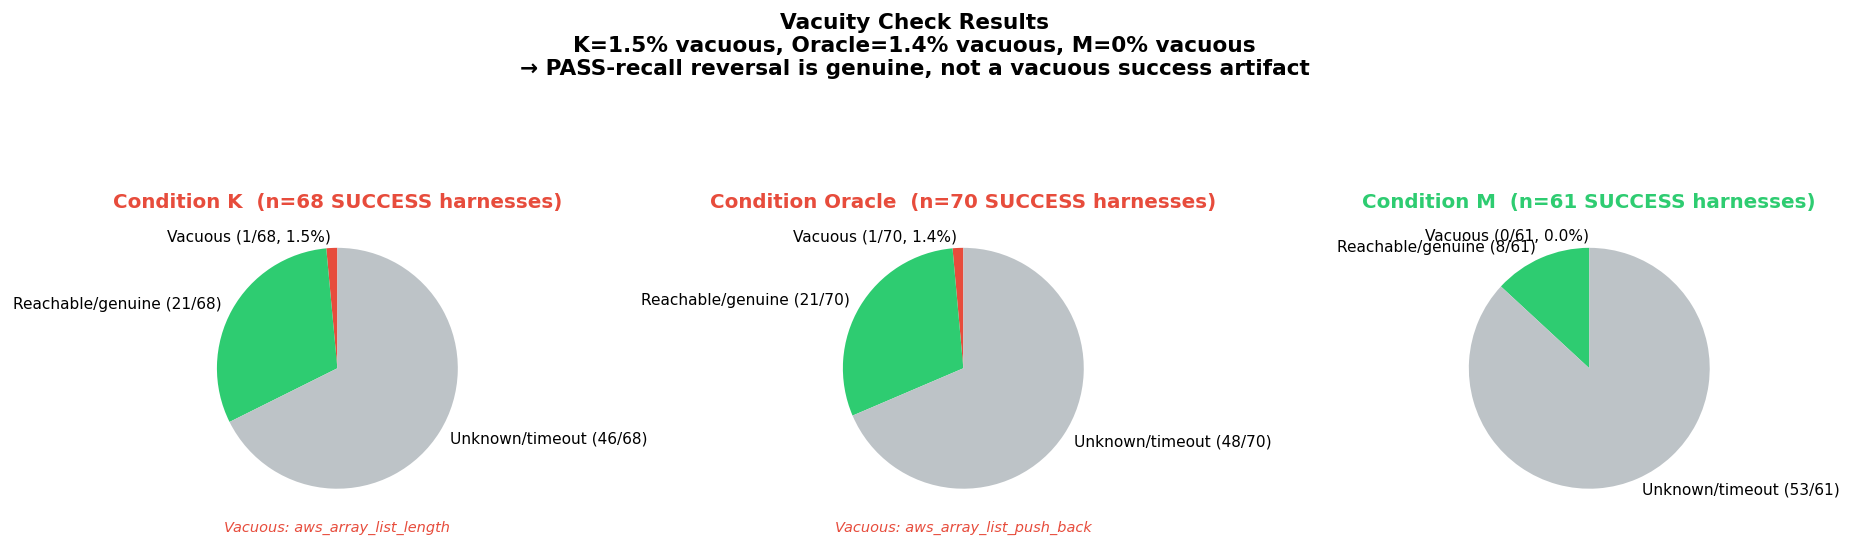

In [15]:
vacuity_summary = {}
for cond in ['K', 'Oracle', 'M']:
    path = os.path.join(EVAL, f'vacuity_check_{cond}_gptoss120b.json')
    with open(path) as f:
        entries = json.load(f)
    total = len(entries)
    vacuous  = [e['func'] for e in entries if e['vacuous'] is True]
    reachable = sum(1 for e in entries if e['vacuous'] is False)
    unknown   = sum(1 for e in entries if e['vacuous'] is None)
    vacuity_summary[cond] = {'total': total, 'vacuous': vacuous,
                              'reachable': reachable, 'unknown': unknown}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (cond, data) in zip(axes, vacuity_summary.items()):
    total = data['total']
    sizes = [len(data['vacuous']), data['reachable'], data['unknown']]
    labels_v = [
        f"Vacuous ({len(data['vacuous'])}/{total}, {100*len(data['vacuous'])/total:.1f}%)",
        f"Reachable/genuine ({data['reachable']}/{total})",
        f"Unknown/timeout ({data['unknown']}/{total})"
    ]
    colors_v = ['#e74c3c', '#2ecc71', '#bdc3c7']
    ax.pie(sizes, labels=labels_v, colors=colors_v, startangle=90,
           textprops={'fontsize': 8.5})
    tc = '#2ecc71' if not data['vacuous'] else '#e74c3c'
    ax.set_title(f'Condition {cond}  (n={total} SUCCESS harnesses)',
                 fontsize=11, fontweight='bold', color=tc)
    if data['vacuous']:
        ax.text(0, -1.35, f"Vacuous: {data['vacuous'][0]}",
                ha='center', fontsize=8, color='#e74c3c', style='italic')

fig.suptitle(
    'Vacuity Check Results\n'
    'K=1.5% vacuous, Oracle=1.4% vacuous, M=0% vacuous\n'
    '→ PASS-recall reversal is genuine, not a vacuous success artifact',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Part 12: The Narrative Arc

How the findings build on each other:

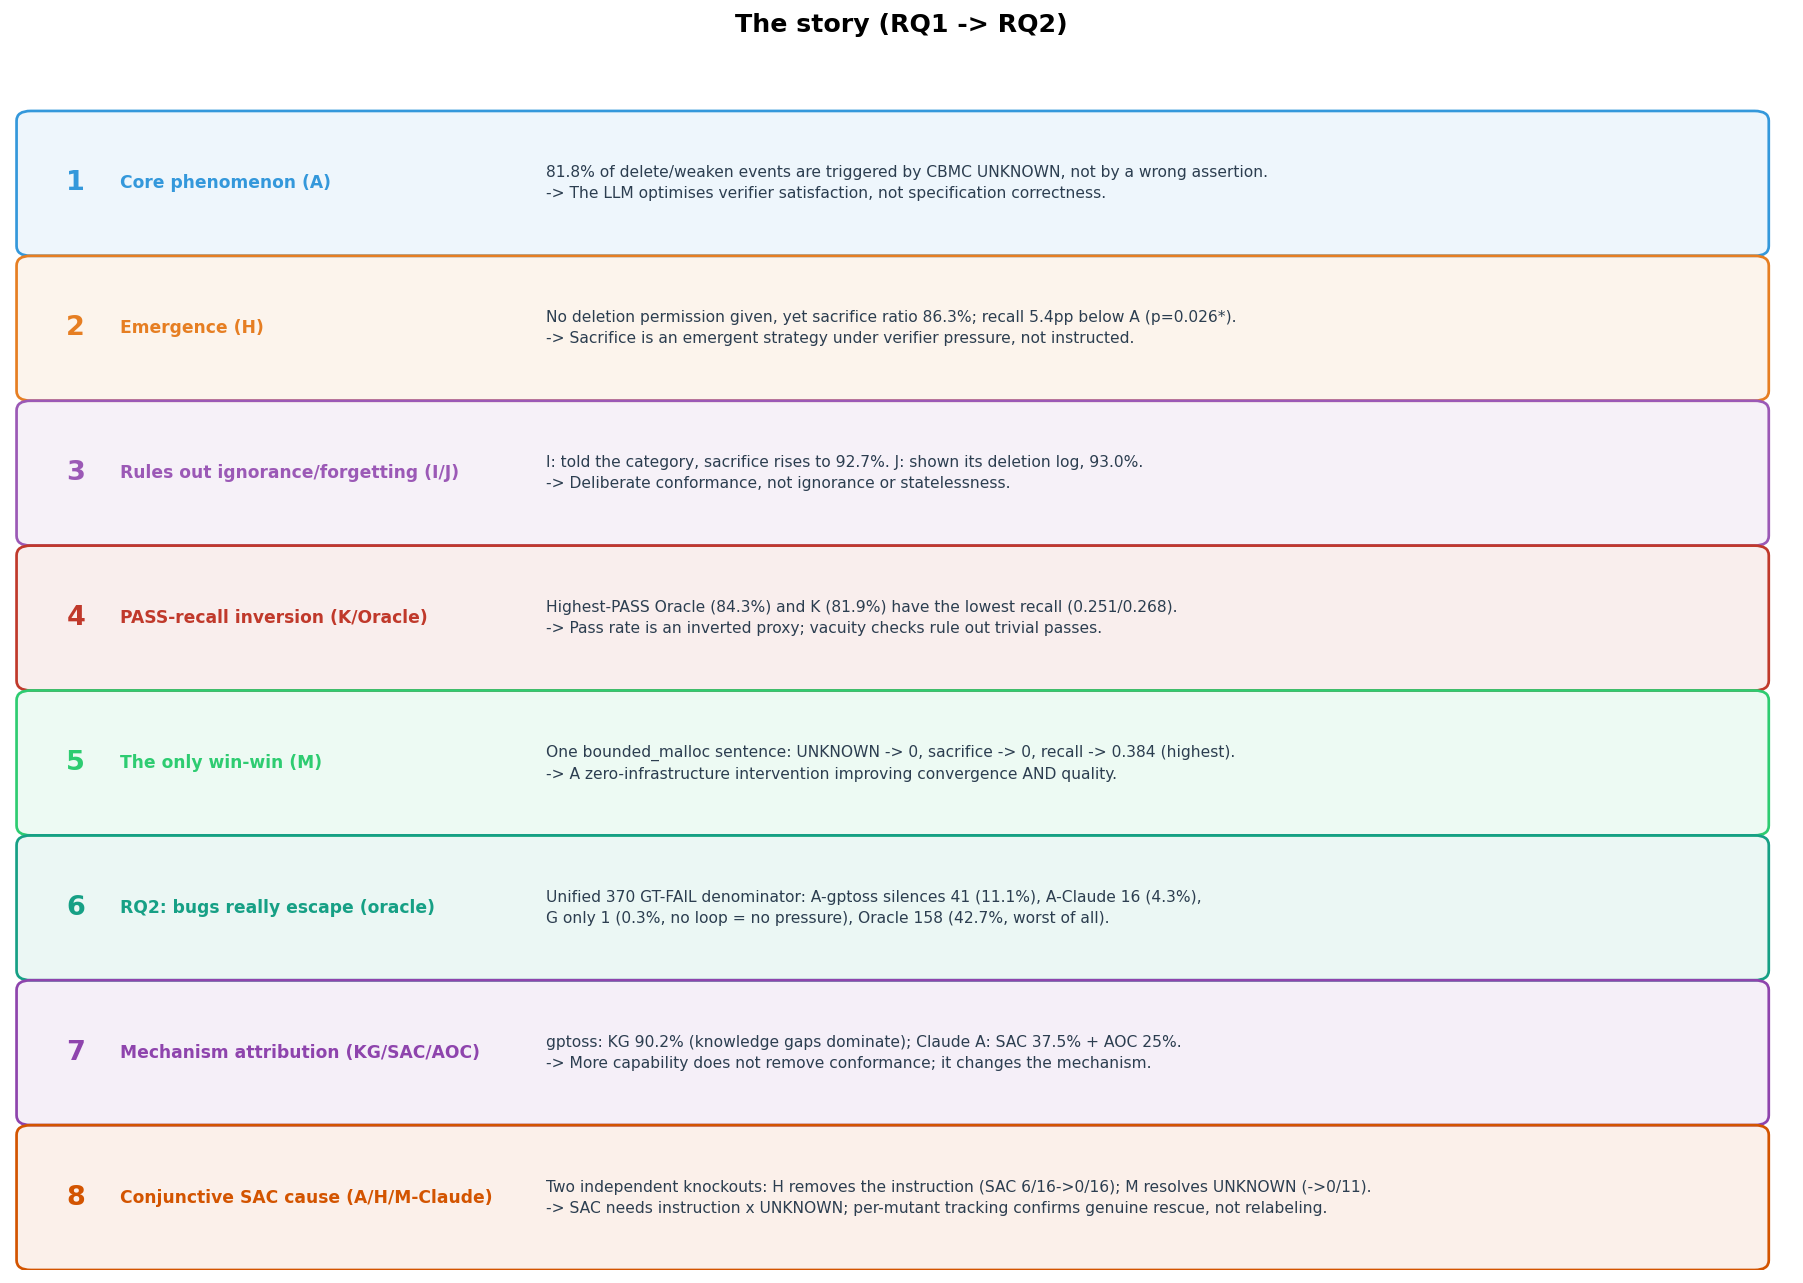

In [16]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')
story = [
    ('1', 'Core phenomenon (A)',
     '81.8% of delete/weaken events are triggered by CBMC UNKNOWN, not by a wrong assertion.\n'
     '-> The LLM optimises verifier satisfaction, not specification correctness.', '#3498db'),
    ('2', 'Emergence (H)',
     'No deletion permission given, yet sacrifice ratio 86.3%; recall 5.4pp below A (p=0.026*).\n'
     '-> Sacrifice is an emergent strategy under verifier pressure, not instructed.', '#e67e22'),
    ('3', 'Rules out ignorance/forgetting (I/J)',
     'I: told the category, sacrifice rises to 92.7%. J: shown its deletion log, 93.0%.\n'
     '-> Deliberate conformance, not ignorance or statelessness.', '#9b59b6'),
    ('4', 'PASS-recall inversion (K/Oracle)',
     'Highest-PASS Oracle (84.3%) and K (81.9%) have the lowest recall (0.251/0.268).\n'
     '-> Pass rate is an inverted proxy; vacuity checks rule out trivial passes.', '#c0392b'),
    ('5', 'The only win-win (M)',
     'One bounded_malloc sentence: UNKNOWN -> 0, sacrifice -> 0, recall -> 0.384 (highest).\n'
     '-> A zero-infrastructure intervention improving convergence AND quality.', '#2ecc71'),
    ('6', 'RQ2: bugs really escape (oracle)',
     'Unified 370 GT-FAIL denominator: A-gptoss silences 41 (11.1%), A-Claude 16 (4.3%),\n'
     'G only 1 (0.3%, no loop = no pressure), Oracle 158 (42.7%, worst of all).', '#16a085'),
    ('7', 'Mechanism attribution (KG/SAC/AOC)',
     'gptoss: KG 90.2% (knowledge gaps dominate); Claude A: SAC 37.5% + AOC 25%.\n'
     '-> More capability does not remove conformance; it changes the mechanism.', '#8e44ad'),
    ('8', 'Conjunctive SAC cause (A/H/M-Claude)',
     'Two independent knockouts: H removes the instruction (SAC 6/16->0/16); M resolves UNKNOWN (->0/11).\n'
     '-> SAC needs instruction x UNKNOWN; per-mutant tracking confirms genuine rescue, not relabeling.', '#d35400'),
]
n = len(story)
row_h = 0.95 / n
for i, (num, title, detail, color) in enumerate(story):
    y = 0.95 - (i + 0.5) * row_h
    ax.add_patch(mpatches.FancyBboxPatch((0.01, y - row_h/2 + 0.008), 0.97, row_h - 0.016,
        boxstyle='round,pad=0.008', linewidth=1.5, edgecolor=color,
        facecolor=color + '15', transform=ax.transAxes))
    ax.text(0.03, y, num, fontsize=15, fontweight='bold', color=color,
            transform=ax.transAxes, va='center')
    ax.text(0.06, y, title, fontsize=9.5, fontweight='bold', color=color,
            transform=ax.transAxes, va='center')
    ax.text(0.30, y, detail, fontsize=8.6, color='#2c3e50',
            transform=ax.transAxes, va='center', linespacing=1.5)
ax.set_title('The story (RQ1 -> RQ2)', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()

---
## Part 13: RQ2 — Mutation oracle results (complete)

**Method (circularity-free mutation oracle)**: universalmutator injects syntactic mutants; after filtering, a unified set of **1,233 valid mutants** (40 functions). For each mutant we run the GT harness and the LLM harness under identical CBMC 5.95.1 configs. **Silenced bug** iff CBMC(GT,m)=FAIL and CBMC(LLM,m)=SUCCESS. All eight conditions share the same per-mutant **GT-FAIL = 370/1233** denominator.

Why circularity-free: we never claim GT is complete — if GT catches what the LLM misses, the triggered GT assertion is a bounded formal certificate that *this* bug was silenced.

Two RQ2 metrics: **Sil/GT** = silenced/370 (lower better); **oracle recall** = LLM-FAIL/GT-FAIL (higher better). Distinct from RQ1's Jaccard-based *assertion recall* (text-level vs behaviour-level).


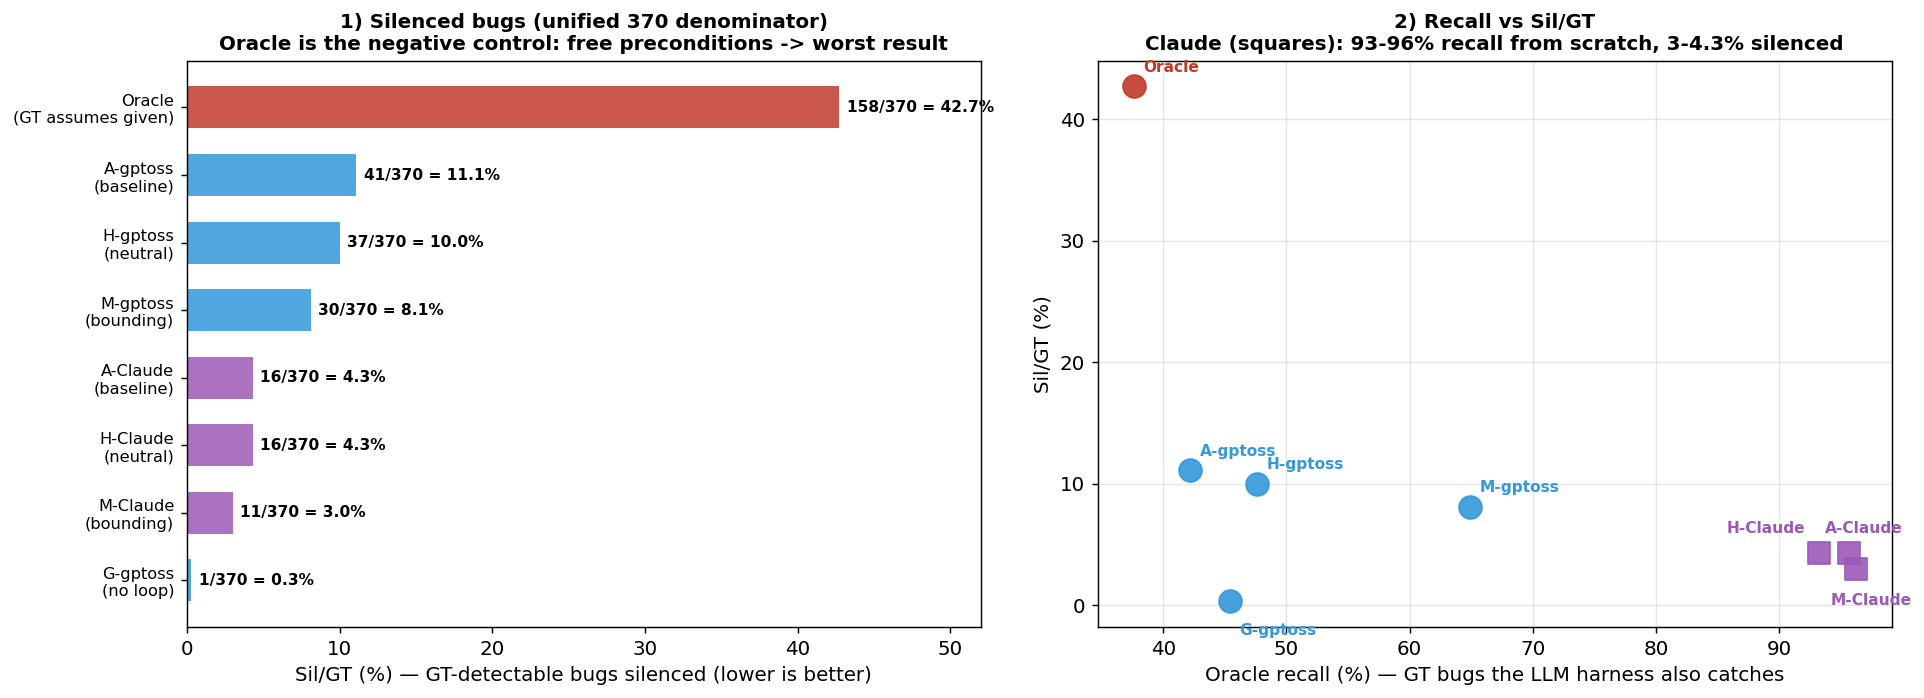

In [17]:
# Canonical RQ2 data (paper.tex Table 6, unified 370 GT-FAIL denominator)
oracle_rows = [
    ('Oracle\n(GT assumes given)', 'gptoss', 158, 42.7, 37.6),
    ('A-gptoss\n(baseline)',        'gptoss',  41, 11.1, 42.2),
    ('H-gptoss\n(neutral)',         'gptoss',  37, 10.0, 47.6),
    ('M-gptoss\n(bounding)',        'gptoss',  30,  8.1, 64.9),
    ('G-gptoss\n(no loop)',         'gptoss',   1,  0.3, 45.4),
    ('A-Claude\n(baseline)',        'claude',  16,  4.3, 95.7),
    ('H-Claude\n(neutral)',         'claude',  16,  4.3, 93.2),
    ('M-Claude\n(bounding)',        'claude',  11,  3.0, 96.2),
]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
rows_sorted = sorted(oracle_rows, key=lambda r: -r[3])
labels = [r[0] for r in rows_sorted]; vals = [r[3] for r in rows_sorted]
cols = ['#c0392b' if 'Oracle' in r[0] else ('#9b59b6' if r[1]=='claude' else '#3498db')
        for r in rows_sorted]
ax.barh(range(len(labels)), vals, color=cols, alpha=0.85, height=0.62)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Sil/GT (%) — GT-detectable bugs silenced (lower is better)')
for i, (v, r) in enumerate(zip(vals, rows_sorted)):
    ax.text(v + 0.5, i, f'{r[2]}/370 = {v:.1f}%', va='center', fontsize=8.5, fontweight='bold')
ax.set_xlim(0, 52); ax.invert_yaxis()
ax.set_title('1) Silenced bugs (unified 370 denominator)\nOracle is the negative control: free preconditions -> worst result',
             fontsize=11, fontweight='bold')
ax = axes[1]
for label, model, sil, silgt, rec in oracle_rows:
    c = '#c0392b' if 'Oracle' in label else ('#9b59b6' if model=='claude' else '#3498db')
    m = 's' if model == 'claude' else 'o'
    ax.scatter(rec, silgt, s=160, color=c, marker=m, zorder=5, alpha=0.9)
    short = label.split('\n')[0]
    offsets = {'A-Claude': (-2.0, 1.6), 'H-Claude': (-7.5, 1.6), 'M-Claude': (-2.0, -3.0),
               'G-gptoss': (0.8, -2.8)}
    dx, dy = offsets.get(short, (0.8, 1.2))
    ax.annotate(short, xy=(rec, silgt), xytext=(rec + dx, silgt + dy),
                fontsize=8.5, fontweight='bold', color=c)
ax.set_xlabel('Oracle recall (%) — GT bugs the LLM harness also catches')
ax.set_ylabel('Sil/GT (%)'); ax.grid(True, alpha=0.3)
ax.set_title('2) Recall vs Sil/GT\nClaude (squares): 93-96% recall from scratch, 3-4.3% silenced',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

### Part 13b: Why does G silence only 1 bug? Verdict decomposition

Silencing requires the LLM harness to return a clean SUCCESS on buggy code. On the same 370 GT-FAIL mutants, G and A catch nearly the same number and have similar compile-error rates — the only difference is that the feedback loop converts G's *loud* outcomes (UNKNOWN/FAIL) into *silent* passes. G's 0.3% is safety-by-failing-loudly, not quality; and the near-identical CE rates (43.5% vs 40.0%) rule out the survivorship-bias explanation.


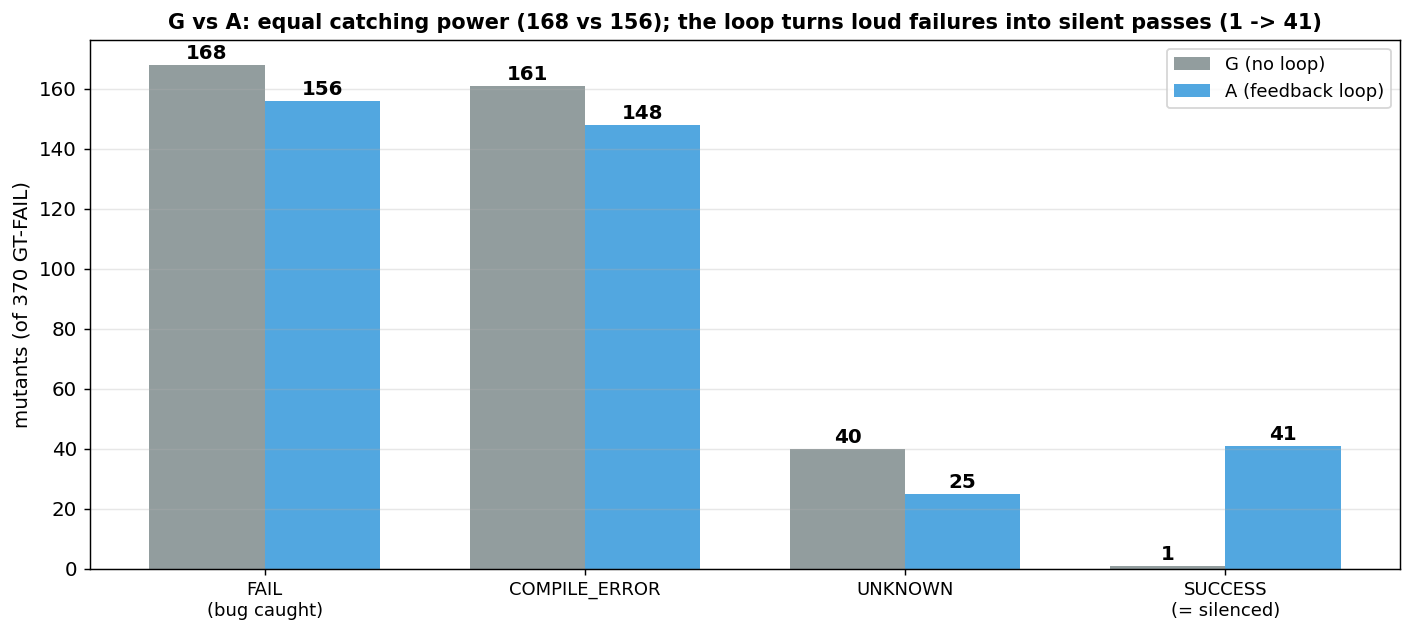

Triggered-property extraction (gt_fail_properties_canonical370.json):
  370/370 verdicts reproduce deterministically; 354 with parsed failing properties (16 regex misses pending)
  Source split: harness-only 110 / harness+library 132 / library-only 112
  -> ~30% of GT detection power comes from proof-helpers / library-internal asserts / libc-model preconditions


In [18]:
verdicts = ['FAIL\n(bug caught)', 'COMPILE_ERROR', 'UNKNOWN', 'SUCCESS\n(= silenced)']
G_vals = [168, 161, 40, 1]; A_vals = [156, 148, 25, 41]
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(verdicts)); w = 0.36
b1 = ax.bar(x - w/2, G_vals, width=w, label='G (no loop)', color='#7f8c8d', alpha=0.85)
b2 = ax.bar(x + w/2, A_vals, width=w, label='A (feedback loop)', color='#3498db', alpha=0.85)
for bars, vals in [(b1, G_vals), (b2, A_vals)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 2, str(v), ha='center', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(verdicts, fontsize=10)
ax.set_ylabel('mutants (of 370 GT-FAIL)')
ax.set_title('G vs A: equal catching power (168 vs 156); the loop turns loud failures into silent passes (1 -> 41)',
             fontsize=11.5, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print('Triggered-property extraction (gt_fail_properties_canonical370.json):')
print('  370/370 verdicts reproduce deterministically; 354 with parsed failing properties (16 regex misses pending)')
print('  Source split: harness-only 110 / harness+library 132 / library-only 112')
print('  -> ~30% of GT detection power comes from proof-helpers / library-internal asserts / libc-model preconditions')

---
## Part 14: Three-mechanism attribution — gptoss and Claude lose bugs on different paths

Each silenced bug is attributed via automated cross-iteration assertion tracking + an AOC detector (assume-envelope comparison): **KG** (never generated), **SAC** (generated then deleted after UNKNOWN), **AOC** (assertions present but `__CPROVER_assume` cuts off the bug-triggering states).


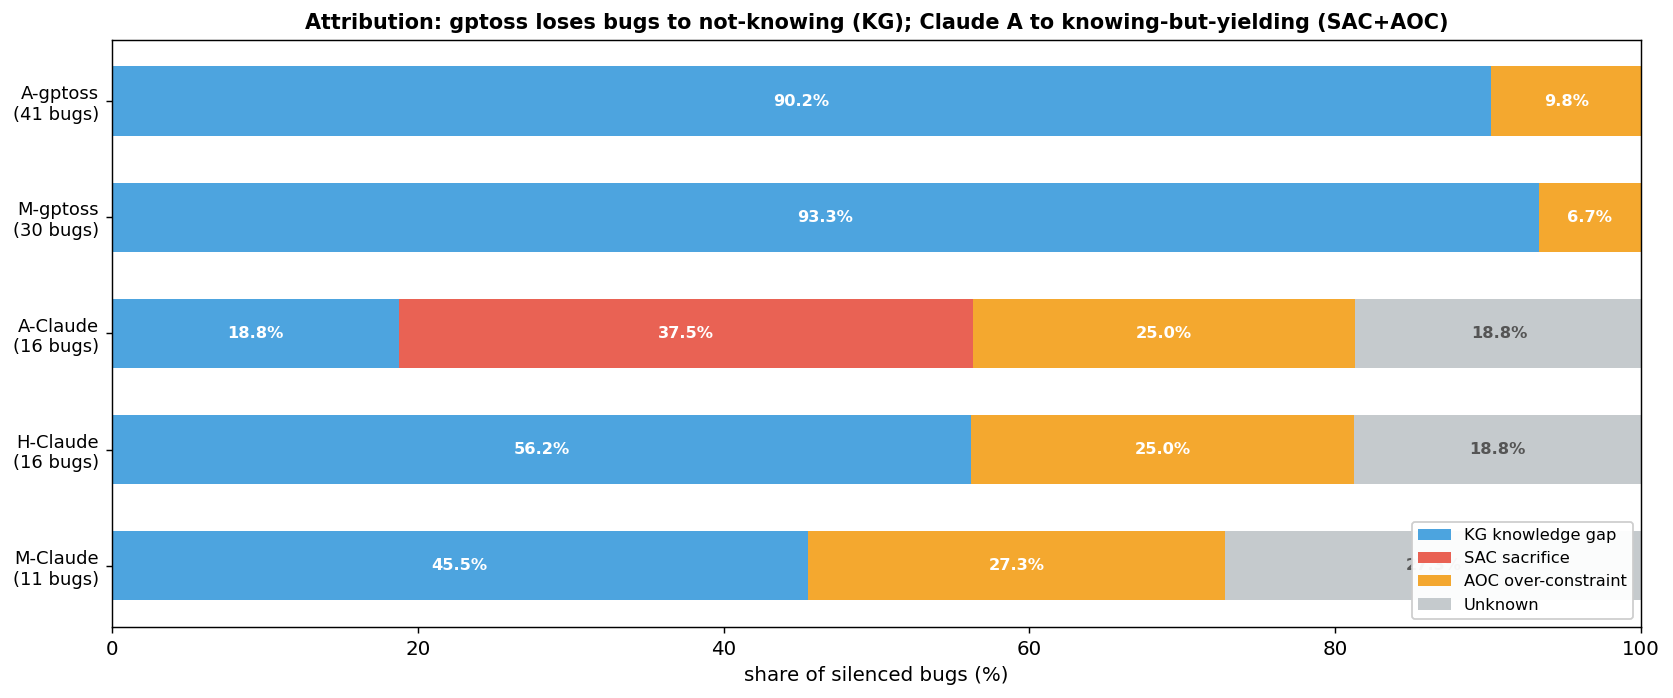

Note: H-Claude still totals 16 silenced — SAC drops to 0 but KG rises 3->9 (see Part 15b).


In [19]:
attr_rows = [
    ('A-gptoss\n(41 bugs)',  90.2,  0.0,  9.8,  0.0),
    ('M-gptoss\n(30 bugs)',  93.3,  0.0,  6.7,  0.0),
    ('A-Claude\n(16 bugs)',  18.8, 37.5, 25.0, 18.8),
    ('H-Claude\n(16 bugs)',  56.2,  0.0, 25.0, 18.8),
    ('M-Claude\n(11 bugs)',  45.5,  0.0, 27.3, 27.3),
]
mech_names  = ['KG knowledge gap', 'SAC sacrifice', 'AOC over-constraint', 'Unknown']
mech_colors = ['#3498db', '#e74c3c', '#f39c12', '#bdc3c7']
fig, ax = plt.subplots(figsize=(13, 5.5))
labels = [r[0] for r in attr_rows]; y = np.arange(len(labels)); left = np.zeros(len(labels))
for k, (mn, mc) in enumerate(zip(mech_names, mech_colors)):
    vals = np.array([r[k+1] for r in attr_rows])
    ax.barh(y, vals, left=left, color=mc, alpha=0.88, height=0.6, label=mn)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v >= 6:
            ax.text(l + v/2, i, f'{v:.1f}%', ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if k != 3 else '#555')
    left += vals
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('share of silenced bugs (%)'); ax.set_xlim(0, 100); ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.set_title('Attribution: gptoss loses bugs to not-knowing (KG); Claude A to knowing-but-yielding (SAC+AOC)',
             fontsize=11.5, fontweight='bold')
plt.tight_layout(); plt.show()
print('Note: H-Claude still totals 16 silenced — SAC drops to 0 but KG rises 3->9 (see Part 15b).')

---
## Part 15: Conjunctive SAC causation — the headline finding (and its limits)

A/H/M (Claude) form three cells of a 2x2 design, each knockout removing one factor:

| | deletion-permitting instruction | no instruction |
|---|---|---|
| **UNKNOWN unresolved** | **A: SAC = 6/16 = 37.5%** [CI 15.2-64.6%] | **H: SAC = 0/16** [CI 0-20.6%] |
| **UNKNOWN resolved (M)** | **M: SAC = 0/11** [CI 0-28.5%] | (unmeasured) |

Removing either factor drives SAC to zero -> SAC requires the **conjunction**. Fisher's exact: A-vs-H p=0.018; A-vs-M p=0.054 (marginal). The causal reading rests on the convergence of the two knockouts plus the per-mutant rescue evidence (Part 15b), not on any single contrast.

Honest limits (in the paper's Limitations): Claude-only; small n; the fourth cell unmeasured; the mechanism-substitution objection is **answered with data** (Part 15b).


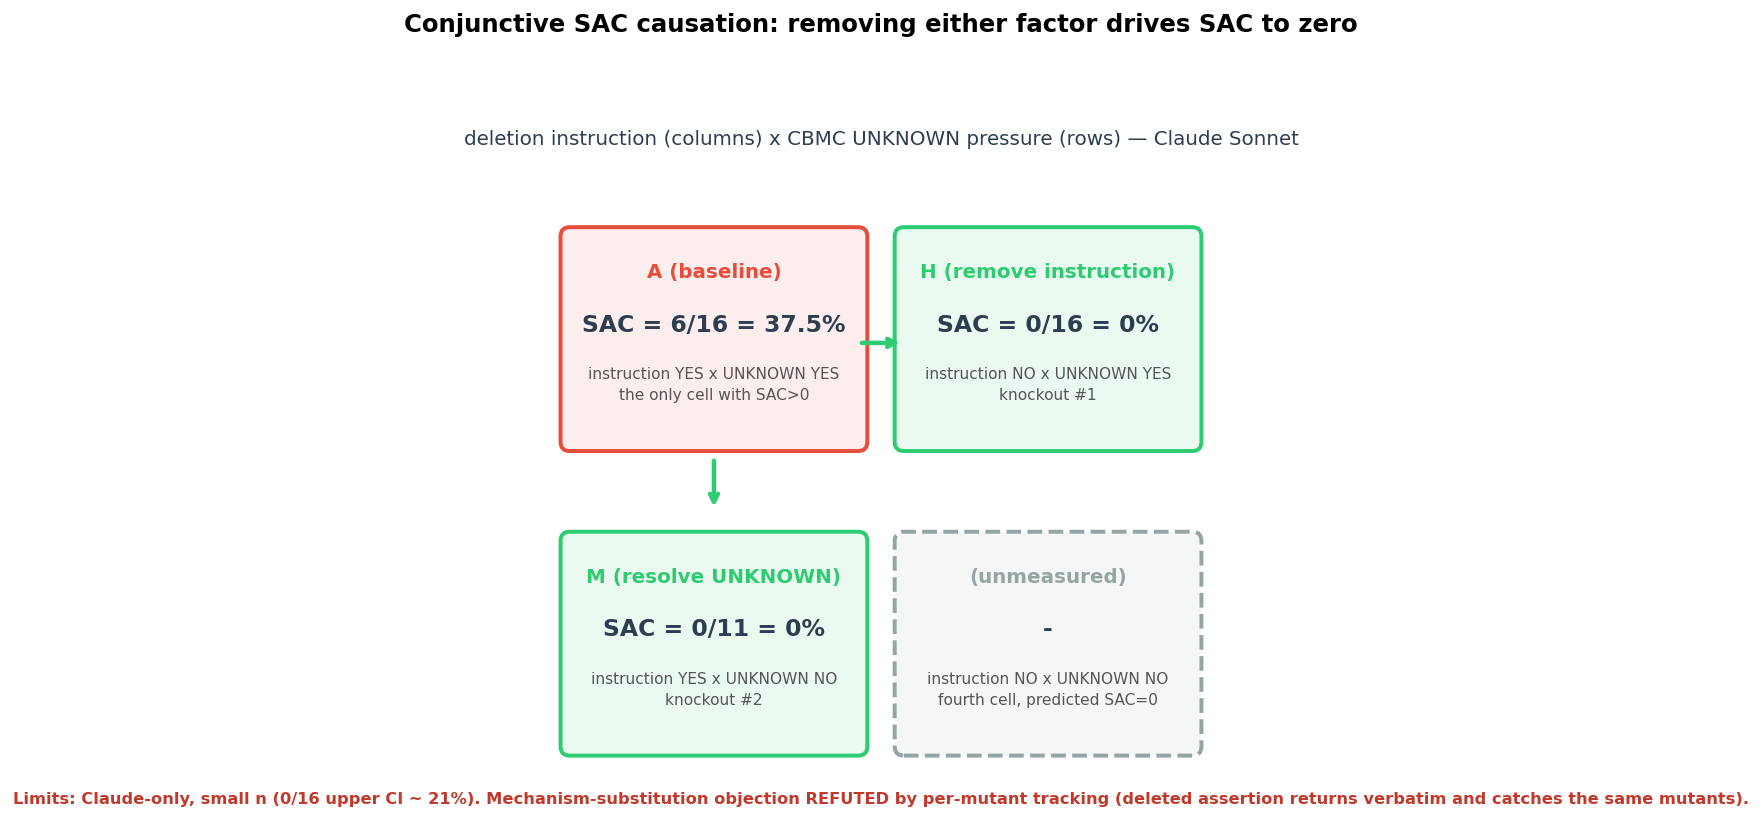

In [20]:
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axis('off')
cells_2x2 = [
    (0.28, 0.62, 'A (baseline)', 'SAC = 6/16 = 37.5%', '#e74c3c', 'instruction YES x UNKNOWN YES\nthe only cell with SAC>0'),
    (0.72, 0.62, 'H (remove instruction)', 'SAC = 0/16 = 0%', '#2ecc71', 'instruction NO x UNKNOWN YES\nknockout #1'),
    (0.28, 0.22, 'M (resolve UNKNOWN)', 'SAC = 0/11 = 0%', '#2ecc71', 'instruction YES x UNKNOWN NO\nknockout #2'),
    (0.72, 0.22, '(unmeasured)', '-', '#95a5a6', 'instruction NO x UNKNOWN NO\nfourth cell, predicted SAC=0'),
]
for x, y, title, val, color, note in cells_2x2:
    ls = 'dashed' if 'unmeasured' in title else 'solid'
    ax.add_patch(mpatches.FancyBboxPatch((x-0.19, y-0.13), 0.38, 0.27,
        boxstyle='round,pad=0.012', linewidth=2.2, linestyle=ls,
        edgecolor=color, facecolor=color + '18', transform=ax.transAxes))
    ax.text(x, y+0.085, title, ha='center', fontsize=11, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(x, y+0.015, val, ha='center', fontsize=13, fontweight='bold',
            color='#2c3e50', transform=ax.transAxes)
    ax.text(x, y-0.075, note, ha='center', fontsize=8.5, color='#555',
            transform=ax.transAxes, linespacing=1.5)
ax.text(0.5, 0.88, 'deletion instruction (columns) x CBMC UNKNOWN pressure (rows) — Claude Sonnet',
        ha='center', fontsize=11, color='#2c3e50', transform=ax.transAxes)
ax.annotate('', xy=(0.53, 0.62), xytext=(0.47, 0.62), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2.5))
ax.annotate('', xy=(0.28, 0.40), xytext=(0.28, 0.47), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2.5))
ax.text(0.5, 0.015,
        'Limits: Claude-only, small n (0/16 upper CI ~ 21%). Mechanism-substitution objection REFUTED'
        ' by per-mutant tracking (deleted assertion returns verbatim and catches the same mutants).',
        ha='center', fontsize=9, color='#c0392b', fontweight='bold', transform=ax.transAxes)
ax.set_title('Conjunctive SAC causation: removing either factor drives SAC to zero',
             fontsize=13.5, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

### Part 15b: Per-mutant rescue verification — answering the relabeling objection

**Objection (simulated DA reviewer, CRITICAL)**: "SAC->0 may be bookkeeping: the same assertion written-then-deleted under A counts as SAC, never-written under H counts as KG — same bugs, new label."

**Verification**: trace each of A-Claude's 16 silenced mutants through H/M oracle results and diff the final harnesses.

**Findings**:
1. **The rescue is genuine**: the assertion A deleted (`assert(buf.len == 0)`, secure_zero) appears **verbatim** in both H's and M's final harnesses, and the 4 corresponding mutants are *caught* (FAIL) under both knockouts; the 2 ring_buffer mutants become COMPILE_ERROR (loud, not silent). **0 SAC bugs were relabeled KG.**
2. **Why H still totals 16**: H rescued 8 but its from-scratch `aws_byte_buf_cat` harness is weaker (11 vs A's 13 assertions, missing two frame conditions and an error-path check) -> 6 new KG losses + 2 new AOC. That is **single-run generation variance**, not relabeling.
3. **Two truths at once**: the conjunction governs *which mechanism* operates; generation variance dominates *which bugs* get silenced — so "SAC is conjunctive" and "H is no safer than A overall" are simultaneously true. M rescues 8 and newly silences only 3 (net -5): still the only net-improving intervention.


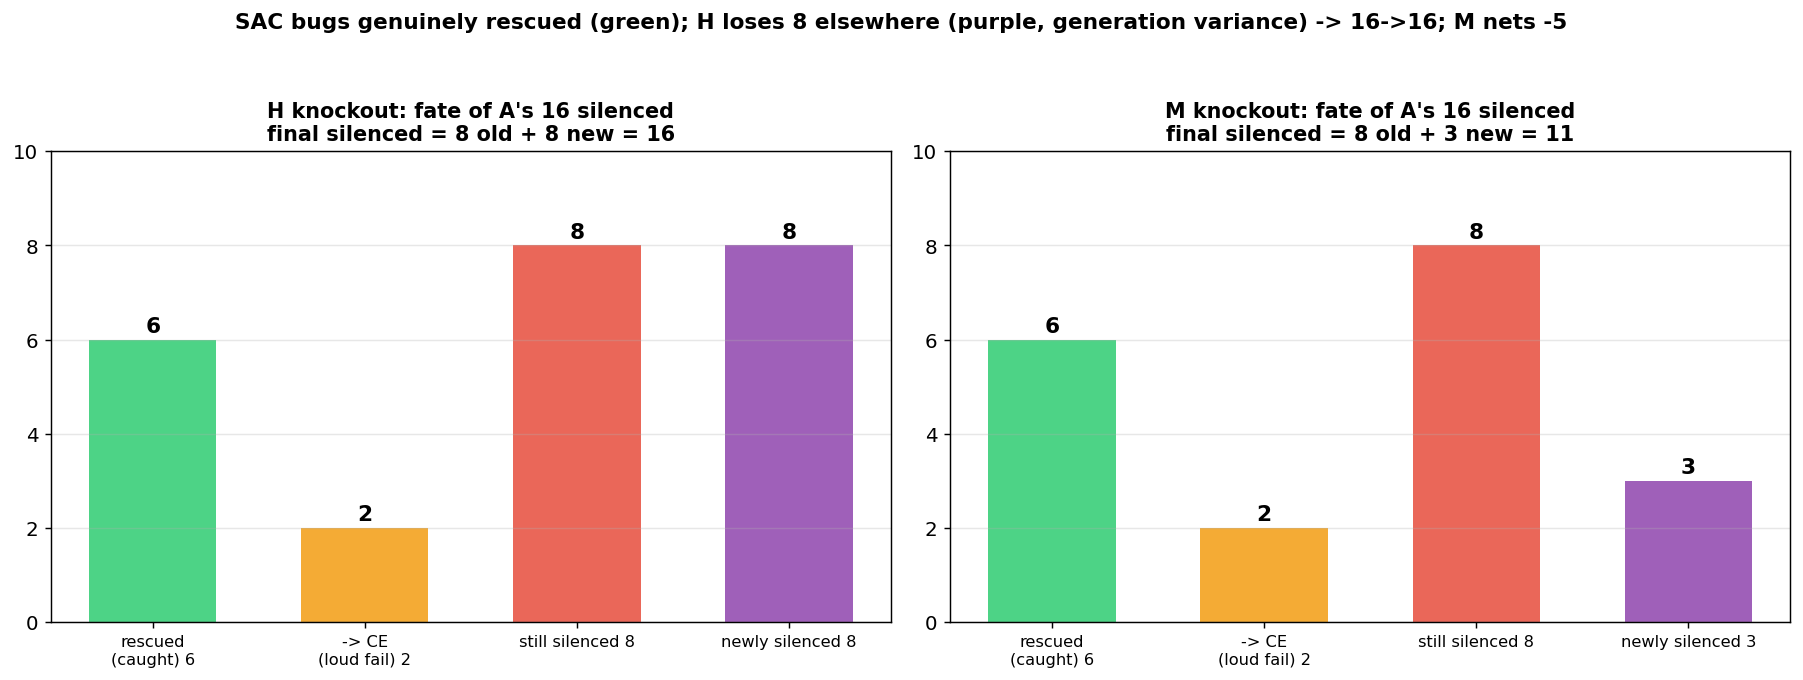

In [21]:
fate_rows = [
    ('secure_zero x4',      'SAC',     'caught',   'caught'),
    ('ring_buffer x2',      'SAC',     'CE',       'CE'),
    ('from_array x2',       'AOC',     'caught',   'caught'),
    ('from_empty_array x2', 'AOC',     'silenced', 'silenced'),
    ('byte_buf_cat x3',     'KG',      'silenced', 'silenced'),
    ('byte_buf_reset x3',   'Unknown', 'silenced', 'silenced'),
]
new_silenced = {'H': 8, 'M': 3}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cond in zip(axes, ['H', 'M']):
    col = 2 if cond == 'H' else 3
    cats = {'caught': 0, 'CE': 0, 'silenced': 0}
    for row in fate_rows:
        n = int(row[0].split('x')[1]); cats[row[col]] += n
    labels = [f'rescued\n(caught) {cats["caught"]}', f'-> CE\n(loud fail) {cats["CE"]}',
              f'still silenced {cats["silenced"]}', f'newly silenced {new_silenced[cond]}']
    vals = [cats['caught'], cats['CE'], cats['silenced'], new_silenced[cond]]
    bars = ax.bar(labels, vals, color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
                  alpha=0.85, width=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.15, str(v), ha='center',
                fontweight='bold', fontsize=12)
    net = cats['silenced'] + new_silenced[cond]
    ax.set_title(f'{cond} knockout: fate of A\'s 16 silenced\n'
                 f'final silenced = {cats["silenced"]} old + {new_silenced[cond]} new = {net}',
                 fontsize=11.5, fontweight='bold')
    ax.set_ylim(0, 10); ax.grid(True, alpha=0.3, axis='y'); ax.tick_params(axis='x', labelsize=9)
fig.suptitle('SAC bugs genuinely rescued (green); H loses 8 elsewhere (purple, generation variance) -> 16->16; M nets -5',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Part 16: Cross-model replication — Llama 3.3 70B (A/G/H)

Purpose: confirm sacrifice is not a gpt-oss-120b artifact. Llama ran the three sacrifice-measurement conditions with RQ1 metrics only (no mutation-oracle data — the paper now says so explicitly where "replication" is claimed).


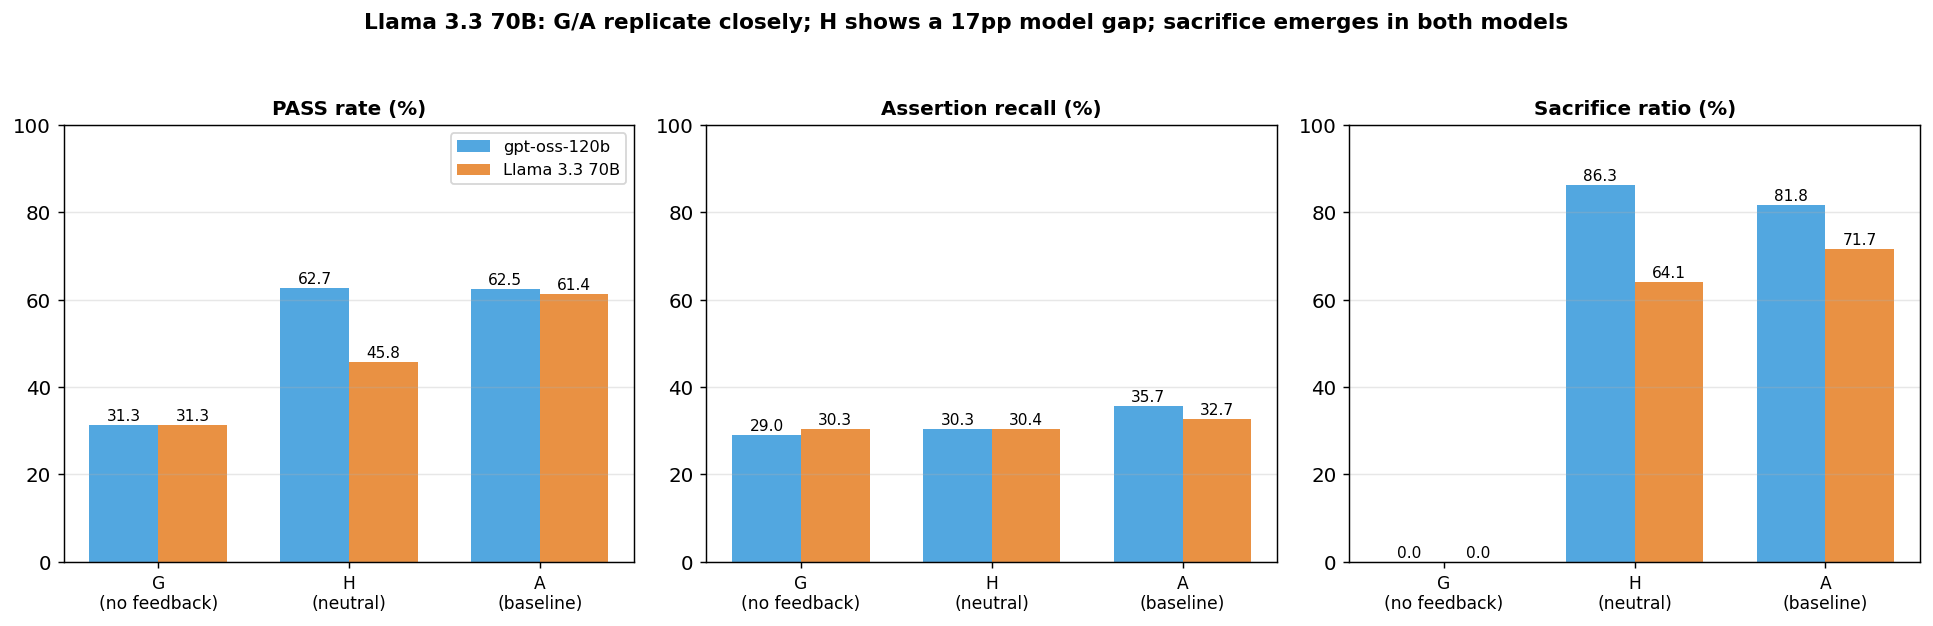

In [22]:
conds = ['G\n(no feedback)', 'H\n(neutral)', 'A\n(baseline)']
gptoss = {'pass': [31.3, 62.7, 62.5], 'recall': [29.0, 30.3, 35.7], 'sac': [0, 86.3, 81.8]}
llama  = {'pass': [31.3, 45.8, 61.4], 'recall': [30.3, 30.4, 32.7], 'sac': [0, 64.1, 71.7]}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
metrics = [('pass', 'PASS rate (%)'), ('recall', 'Assertion recall (%)'), ('sac', 'Sacrifice ratio (%)')]
x = np.arange(len(conds)); w = 0.36
for ax, (key, title) in zip(axes, metrics):
    ax.bar(x - w/2, gptoss[key], width=w, label='gpt-oss-120b', color='#3498db', alpha=0.85)
    ax.bar(x + w/2, llama[key],  width=w, label='Llama 3.3 70B', color='#e67e22', alpha=0.85)
    for i in range(len(conds)):
        ax.text(i - w/2, gptoss[key][i] + 1, f'{gptoss[key][i]:.1f}', ha='center', fontsize=8.5)
        ax.text(i + w/2, llama[key][i] + 1,  f'{llama[key][i]:.1f}',  ha='center', fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(conds, fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 100); ax.grid(True, alpha=0.3, axis='y')
axes[0].legend(fontsize=9)
fig.suptitle('Llama 3.3 70B: G/A replicate closely; H shows a 17pp model gap; sacrifice emerges in both models',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Part 17: Experiment map — RQ, metrics, and what each condition proved


In [23]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
rows = [
 ('A', 'gptoss/Claude/Llama', '— (baseline: iterative loop + deletion permission)', 'RQ1+RQ2',
  'pass/recall/sacrifice; Sil/GT, oracle recall, attribution',
  'gptoss 62.5%/0.357/81.8%; 41 silenced (11.1%); Claude 16 (4.3%, SAC 37.5%)',
  'Existence and scale of the conformance phenomenon'),
 ('G', 'gptoss/Llama', 'remove the feedback loop (single pass)', 'RQ1+RQ2',
  'pass/recall; Sil/GT', '31.3%/0.290; 1 silenced (0.3%)',
  'The loop is the source of conformance pressure (and of false passes)'),
 ('H', 'gptoss/Claude/Llama', 'remove the deletion-permitting instruction', 'RQ1+RQ2',
  'sacrifice; deletion Wilcoxon; Sil/GT; SAC attribution',
  'sacrifice 86.3%; deletions A>H p=0.014; Sil/GT 10.0 vs 11.1% p=0.090 n.s.; Claude SAC 0/16',
  'Sacrifice is emergent; SAC knockout #1'),
 ('I', 'gptoss', 'inject GT assertion-category label at each UNKNOWN', 'RQ1',
  'sacrifice; deletion scope', '92.7% (up); scope 6.7->5.5',
  'Rules out ignorance: knows the category, deletes anyway'),
 ('J', 'gptoss', 'append full deletion history', 'RQ1',
  'sacrifice; recall', '93.0%; J>H recall p=0.006**',
  'Rules out statelessness; context only secondary protection'),
 ('K', 'gptoss', 'NL contract before assertions (spec-first)', 'RQ1',
  'pass/recall/sacrifice/over-constraint/vacuity',
  '81.9% pass / 0.268 recall / 25% sacrifice / 31.3% over-constrained',
  'Second high-pass-low-recall instance; NL contract incomplete + over-constrains'),
 ('M', 'gptoss/Claude', 'one bounded_malloc sentence in the prompt', 'RQ1+RQ2',
  'all RQ1 + Sil/GT, oracle recall, SAC attribution',
  'UNKNOWN->0, sacrifice 0%, recall 0.384; oracle recall 42.2->64.9%; Claude SAC 0/11',
  'The only win-win intervention; SAC knockout #2'),
 ('Oracle', 'gptoss', 'hand over GT __CPROVER_assume preconditions', 'RQ1+RQ2',
  'pass/recall/vacuity; Sil/GT',
  '84.3% pass (highest) / 0.251 recall (lowest) / 158 silenced = 42.7% (highest)',
  'Negative control: free preconditions induce laziness, not safety'),
 ('Llama A/G/H', 'Llama 3.3 70B', 'swap the model', 'replication',
  'pass/recall/sacrifice (no oracle)', 'G/A replicate <2pp; H 17pp gap; sacrifice 64-72%',
  'Sacrifice is cross-model, not a gptoss artifact'),
 ('Vacuity check', 'gptoss', 'assert(false) before the call', 'RQ1 validity',
  'vacuous fraction', 'K 1/68, Oracle 1/70, M 0',
  'Rules out trivial-pass artifacts'),
 ('Cloze test', '—', 'blank one GT assertion, ask LLM to fill', 'RQ2 follow-up',
  'fill rate per KG category', '(pending, script ready)',
  'Separates placement failure from knowledge failure'),
 ('s2n-tls', '—', 'swap the corpus (protocol code)', 'external validity',
  'same RQ1/RQ2', '(pending, task #20)', 'Tests generalisation beyond buffer-centric code'),
]
df = pd.DataFrame(rows, columns=['Experiment', 'Model(s)', 'Single variable vs A', 'RQ',
                                  'Key metrics', 'Result', 'What it established'])
from IPython.display import HTML
HTML(df.to_html(index=False).replace('<th>', '<th style="text-align:left;background:#2c3e50;color:white">')
                            .replace('<td>', '<td style="text-align:left;vertical-align:top">'))

Experiment,Model(s),Single variable vs A,RQ,Key metrics,Result,What it established
A,gptoss/Claude/Llama,— (baseline: iterative loop + deletion permission),RQ1+RQ2,"pass/recall/sacrifice; Sil/GT, oracle recall, attribution","gptoss 62.5%/0.357/81.8%; 41 silenced (11.1%); Claude 16 (4.3%, SAC 37.5%)",Existence and scale of the conformance phenomenon
G,gptoss/Llama,remove the feedback loop (single pass),RQ1+RQ2,pass/recall; Sil/GT,31.3%/0.290; 1 silenced (0.3%),The loop is the source of conformance pressure (and of false passes)
H,gptoss/Claude/Llama,remove the deletion-permitting instruction,RQ1+RQ2,sacrifice; deletion Wilcoxon; Sil/GT; SAC attribution,sacrifice 86.3%; deletions A>H p=0.014; Sil/GT 10.0 vs 11.1% p=0.090 n.s.; Claude SAC 0/16,Sacrifice is emergent; SAC knockout #1
I,gptoss,inject GT assertion-category label at each UNKNOWN,RQ1,sacrifice; deletion scope,92.7% (up); scope 6.7->5.5,"Rules out ignorance: knows the category, deletes anyway"
J,gptoss,append full deletion history,RQ1,sacrifice; recall,93.0%; J>H recall p=0.006**,Rules out statelessness; context only secondary protection
K,gptoss,NL contract before assertions (spec-first),RQ1,pass/recall/sacrifice/over-constraint/vacuity,81.9% pass / 0.268 recall / 25% sacrifice / 31.3% over-constrained,Second high-pass-low-recall instance; NL contract incomplete + over-constrains
M,gptoss/Claude,one bounded_malloc sentence in the prompt,RQ1+RQ2,"all RQ1 + Sil/GT, oracle recall, SAC attribution","UNKNOWN->0, sacrifice 0%, recall 0.384; oracle recall 42.2->64.9%; Claude SAC 0/11",The only win-win intervention; SAC knockout #2
Oracle,gptoss,hand over GT __CPROVER_assume preconditions,RQ1+RQ2,pass/recall/vacuity; Sil/GT,84.3% pass (highest) / 0.251 recall (lowest) / 158 silenced = 42.7% (highest),"Negative control: free preconditions induce laziness, not safety"
Llama A/G/H,Llama 3.3 70B,swap the model,replication,pass/recall/sacrifice (no oracle),G/A replicate <2pp; H 17pp gap; sacrifice 64-72%,"Sacrifice is cross-model, not a gptoss artifact"
Vacuity check,gptoss,assert(false) before the call,RQ1 validity,vacuous fraction,"K 1/68, Oracle 1/70, M 0",Rules out trivial-pass artifacts


---
## Part 18: Metrics cheat-sheet

| Metric | Definition | Denominator | Answers | Limits |
|---|---|---|---|---|
| **Pass rate** | final-iteration CBMC=UNSAT | 83 functions | convergence | inversely related to quality (core finding) |
| **Assertion recall** | Jaccard>=0.45 match vs GT asserts | GT assertions | spec-text completeness | text match misses semantic equivalents; 0.45 unswept |
| **Sacrifice ratio** | UNKNOWN-triggered deletes / all deletes | deletion events | motive for deletion | != safety damage (gptoss deletes mostly inert asserts) |
| **Over-constraint** | assume tighter than GT | functions | AOC risk surface | benign-bounding vs AOC criterion = future work |
| **Deletion scope** | asserts deleted per UNKNOWN event | deletion events | panic vs targeted | — |
| **Vacuity** | call unreachable under assumes | SUCCESS harnesses | rules out trivial passes | — |
| **Sil/GT** ⭐ | GT-FAIL ∧ LLM-SUCCESS | unified 370 | bugs actually escaping | ~15-20% equivalent-mutant upper bound, adjudication pending |
| **Oracle recall** ⭐ | LLM-FAIL / GT-FAIL | unified 370 | behavioural bug-catching | relative to GT-detectable set |
| **KG/SAC/AOC** | cross-iteration tracking + assume diff | silenced bugs | which path lost the bug | algorithm prose-only; Unknown bucket 18.8-27.3% |


---
## Part 19: Summary + simulated review status

| Step | Measures | Key result |
|---|---|---|
| Feedback loop (A) | iterative harness generation | converges, but 81.8% of deletions are UNKNOWN-triggered |
| Emergence + ablations (H/I/J) | instructed? ignorant? forgetful? | none — emergent, deliberate conformance |
| PASS vs recall (K/Oracle) | is pass rate a quality proxy? | no — inverted; vacuity checks rule out artifacts |
| M | fix the CBMC knowledge gap | the only win-win; UNKNOWN and sacrifice both -> 0 |
| **RQ2 oracle (370)** | do bugs really escape? | yes: 41 (gptoss A) / 16 (Claude A), each formally certified |
| **Attribution** | which path? | gptoss -> KG 90.2%; Claude -> SAC 37.5% + AOC 25% |
| **Conjunctive SAC** | what causes SAC? | instruction x UNKNOWN; rescue verified per-mutant |
| **Oracle negative control** | are free preconditions safer? | no — 42.7% Sil/GT, worst of all eight |
| Llama replication | gptoss-specific? | no |

**Simulated 5-reviewer panel trajectory (ARS plugin, 2026-06-11)**:
- Full panel: **Major Revision** (R1/R2 Major; DA 3 CRITICAL incl. mechanism substitution)
- After rescue analysis + property extraction + G decomposition + abstract softening: rubric **73.55 -> Minor Revision**
- After statistics pass (rank-biserial r, Holm correction — A>Oracle/A>K/A>H lose significance, M-family survives; Clopper-Pearson CIs; Fisher A-H p=0.018, A-M p=0.054 marginal; null-result rewording with paired-diff CI [0.0, 3.6]pp) + consistency cleanup + 4 references (nl2postcond, SpecGen, mCoq, vacuity): rubric **78.60 — top of Minor Revision band** (O 83 / M 76 / E 79 / C 78 / W 77)
- Remaining to cross 80: UNKNOWN operationalization text, 50-sample equivalent-mutant adjudication, repeated-run variance, cloze test, s2n-tls.

**Central claim**: LLMs under iterative verifier feedback optimise for verifier satisfaction rather than specification completeness — and pass rate is an inverted proxy for safety.
